## Credit Risk Prediction using Explainable Machine Learning (Interpretable vs Black-Box Models)
#### A Comparative Analysis using SHAP and LIME 
Author: Parabha Krairiksh

Student ID : s4162192

Supervisor: Dr. Xin Zheng

Institution: RMIT University - School of Computing Technologies

Dataset: Home Credit Default Risk (Kaggle)

Date: May, 2026

#### Set up & Imports


In [1]:
import subprocess
import sys

required = ['xgboost', 'lightgbm', 'shap', 'lime']
for package in required:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"{package} installed")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score,
    roc_curve, classification_report
)
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# metric helper
def compute_metrics(model_name, y_true, y_prob, y_pred):
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    default_probs    = y_prob[y_true == 1]
    nondefault_probs = y_prob[y_true == 0]
    ks_stat, _       = ks_2samp(default_probs, nondefault_probs)
    f1 = f1_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  Gini    : {gini:.4f}")
    print(f"  KS Stat : {ks_stat:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    return {
        'Model'   : model_name,
        'AUC-ROC' : round(auc, 4),
        'Gini'    : round(gini, 4),
        'KS Stat' : round(ks_stat, 4),
        'F1 Score': round(f1, 4)
    }

results = []
print("\nSetup complete — ready to train models")


Setup complete — ready to train models


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

# plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries loaded successfully")


Libraries loaded successfully


In [3]:
df = pd.read_csv('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/application_train.csv')

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows:    307,511
Columns: 122


In [4]:
import os
print(os.getcwd())

/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML


## Section 1: Exploratory Data Analysis (EDA)
**Dataset:** Home Credit Default Risk - 'application_train.csv'

**Source:** Home Credit Group via Kaggle

**Citation:** Home Credit Group (2018). *Home Credit Default Risk*[Dataset]. Kaggle. https://www.kaggle.com/c/home-credit-default-risk

Coverage:
1. Load and inspect the raw dataset.
2. Check the target variables distribution (numeric vs categorical)
3. Identify feature types (numeric vs categorical)
4. Analyse missing values per column
5. Examine correlations with target variable
6. Produce EDA Summary

Key Decisions:
- Columns with >40% missing values will be dropped in preprocessing.
- EXT_SOURCE_1 retained despite high numbers of missing values (credit bureu score)
- Class imbalance (~8%) confirms need for class weighting strategy.

In [5]:
df.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,NaN,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.6504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [7]:
df.describe()


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,...,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307499.0000,307233.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,104582.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307509.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,134133.0000,306851.0000,246546.0000,151450.0000,127568.0000,157504.0000,103023.0000,92646.0000,143620.0000,152683.0000,154491.0000,98869.0000,124921.0000,97312.0000,153161.0000,93997.0000,137829.0000,151450.0000,127568.0000,157504.0000,103023.0000,...,97312.0000,153161.0000,93997.0000,137829.0000,151450.0000,127568.0000,157504.0000,103023.0000,92646.0000,143620.0000,152683.0000,154491.0000,98869.0000,124921.0000,97312.0000,153161.0000,93997.0000,137829.0000,159080.0000,306490.0000,306490.0000,306490.0000,306490.0000,307510.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,265992.0000,265992.0000,265992.0000,265992.0000,265992.0000,265992.0000
mean,278180.5186,0.0807,0.4171,168797.9193,599025.9997,27108.5739,538396.2074,0.0209,-16036.9951,63815.0459,-4986.1203,-2994.2024,12.0611,1.0000,0.8199,0.1994,0.9981,0.2811,0.0567,2.1527,2.0525,2.0315,12.0634,0.0151,0.0508,0.0407,0.0782,0.2305,0.1796,0.5021,0.5144,0.5109,0.1174,0.0884,0.9777,0.7525,0.0446,0.0789,0.1497,0.2263,0.2319,0.0663,0.1008,0.1074,0.0088,0.0284,0.1142,0.0875,0.9771,0.7596,...,0.1056,0.1060,0.0081,0.0270,0.1178,0.0880,0.9778,0.7557,0.0446,0.0781,0.1492,0.2259,0.2316,0.0672,0.1020,0.1086,0.0087,0.0282,0.1025,1.4222,0.1434,1.4053,0.1000,-962.8588,0.0000,0.7100,0.0001,0.0151,0.0881,0.0002,0.0814,0.0039,0.0000,0.0039,0.0000,0.0035,0.0029,0.0012,0.0099,0.0003,0.0081,0.0006,0.0005,0.0003,0.0064,0.0070,0.0344,0.2674,0.2655,1.9000
std,102790.1753,0.2724,0.7221,237123.1463,402490.7770,14493.7373,369446.4605,0.0138,4363.9886,141275.7665,3522.8863,1509.4504,11.9448,0.0018,0.3843,0.3995,0.0432,0.4495,0.2313,0.9107,0.5090,0.5027,3.2658,0.1221,0.

In [8]:
print("Target distribution:")
print(df['TARGET'].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean():.2%}")
print(f"Non-default:  {(df['TARGET'] == 0).sum():,}")
print(f"Default:      {(df['TARGET'] == 1).sum():,}")


Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%
Non-default:  282,686
Default:      24,825


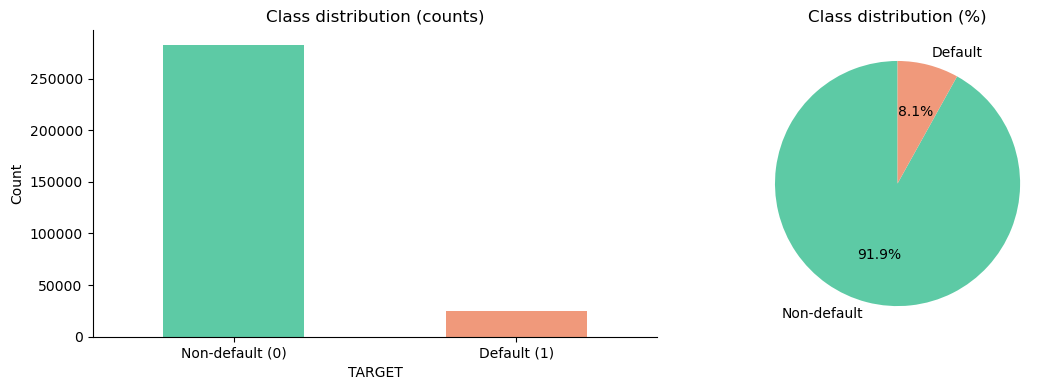

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['TARGET'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#5DCAA5', '#F0997B'],
    edgecolor='none'
)
axes[0].set_title('Class distribution (counts)')
axes[0].set_xticklabels(['Non-default (0)', 'Default (1)'], rotation=0)
axes[0].set_ylabel('Count')

axes[1].pie(
    df['TARGET'].value_counts(),
    labels=['Non-default', 'Default'],
    autopct='%1.1f%%',
    colors=['#5DCAA5', '#F0997B'],
    startangle=90
)
axes[1].set_title('Class distribution (%)')

plt.tight_layout()
plt.show()

In [10]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing_cols = missing[missing['missing_count'] > 0]
print(f"Columns with missing values: {len(missing_cols)}")
print(missing_cols.head(20))

Columns with missing values: 67
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865      69.8700
COMMONAREA_AVG                   214865      69.8700
COMMONAREA_MODE                  214865      69.8700
NONLIVINGAPARTMENTS_MODE         213514      69.4300
NONLIVINGAPARTMENTS_AVG          213514      69.4300
NONLIVINGAPARTMENTS_MEDI         213514      69.4300
FONDKAPREMONT_MODE               210295      68.3900
LIVINGAPARTMENTS_MODE            210199      68.3500
LIVINGAPARTMENTS_AVG             210199      68.3500
LIVINGAPARTMENTS_MEDI            210199      68.3500
FLOORSMIN_AVG                    208642      67.8500
FLOORSMIN_MODE                   208642      67.8500
FLOORSMIN_MEDI                   208642      67.8500
YEARS_BUILD_MEDI                 204488      66.5000
YEARS_BUILD_MODE                 204488      66.5000
YEARS_BUILD_AVG                  204488      66.5000
OWN_CAR_AGE                      202929      65.9900
LANDAREA_MEDI 

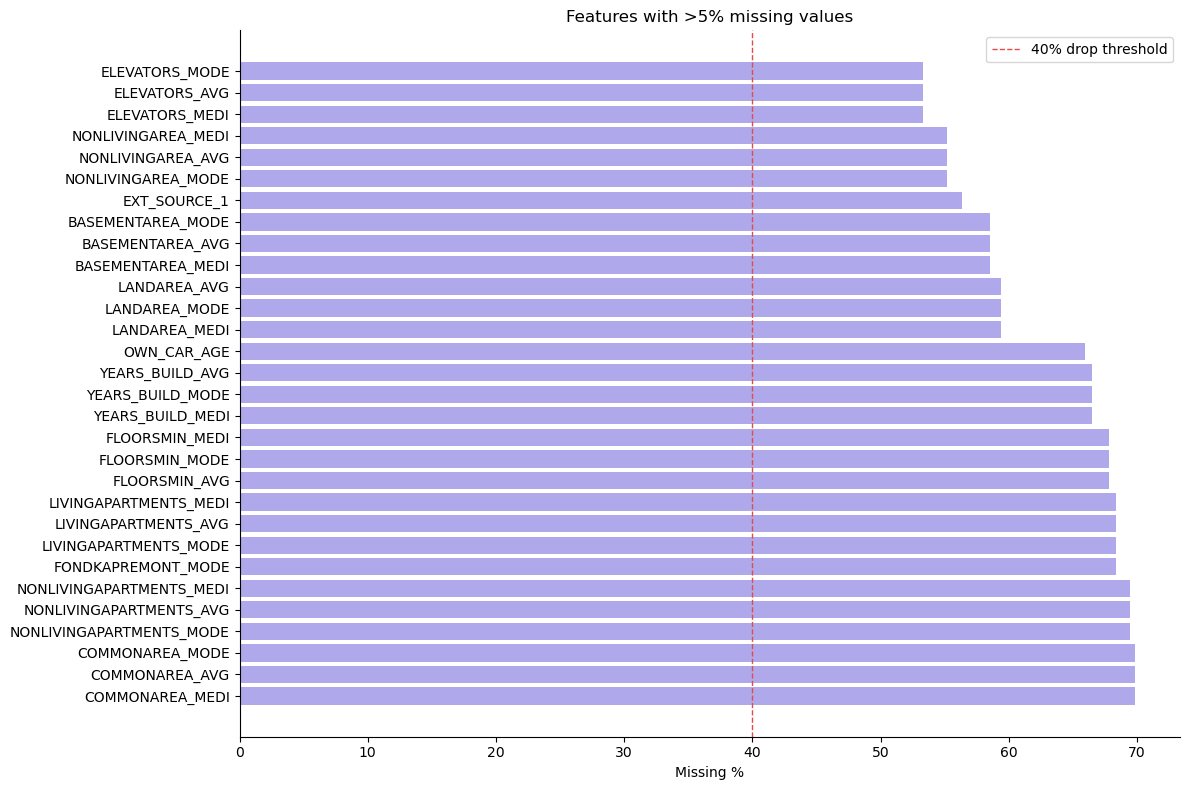

In [11]:
# columns with more than 5% missing
to_plot = missing[missing['missing_pct'] > 5].head(30)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(to_plot.index, to_plot['missing_pct'], color='#AFA9EC', edgecolor='none')
ax.axvline(x=40, color='#E24B4A', linestyle='--', linewidth=1, label='40% drop threshold')
ax.set_xlabel('Missing %')
ax.set_title('Features with >5% missing values')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# correlation with target
exclude = ['SK_ID_CURR', 'TARGET']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr = df[numeric_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
corr_abs = corr.abs().sort_values(ascending=False)

print("Top 15 features correlated with TARGET:")
print(corr_abs.head(15).round(4))

Top 15 features correlated with TARGET:
EXT_SOURCE_3                  0.1789
EXT_SOURCE_2                  0.1605
EXT_SOURCE_1                  0.1553
DAYS_BIRTH                    0.0782
REGION_RATING_CLIENT_W_CITY   0.0609
REGION_RATING_CLIENT          0.0589
DAYS_LAST_PHONE_CHANGE        0.0552
DAYS_ID_PUBLISH               0.0515
REG_CITY_NOT_WORK_CITY        0.0510
FLAG_EMP_PHONE                0.0460
DAYS_EMPLOYED                 0.0449
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_DOCUMENT_3               0.0443
FLOORSMAX_AVG                 0.0440
FLOORSMAX_MEDI                0.0438
Name: TARGET, dtype: float64


In [13]:
exclude = ['SK_ID_CURR', 'TARGET']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude]
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)
drop_threshold = 40
drop_cols = missing[missing['missing_pct'] > drop_threshold].index.tolist()

print("=" * 50)
print("EDA SUMMARY — copy this into your methodology")
print("=" * 50)
print(f"Total rows:                {len(df):,}")
print(f"Total columns:             {df.shape[1]}")
print(f"Numeric features:          {len(numeric_cols)}")
print(f"Categorical features:      {len(categorical_cols)}")
print(f"Default rate:              {df['TARGET'].mean():.2%}")
print(f"Columns >40% missing:      {len(drop_cols)}")
print(f"Columns to drop:           {drop_cols}")
print("=" * 50)

EDA SUMMARY — copy this into your methodology
Total rows:                307,511
Total columns:             122
Numeric features:          104
Categorical features:      16
Default rate:              8.07%
Columns >40% missing:      49
Columns to drop:           ['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'LANDAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'EXT_SOURCE_1', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'ELEVATORS_MEDI', 'ELEVATORS_AVG', 'ELEVATORS_MODE', 'WALLSMATERIAL_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'APARTMENTS_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'ENTRANCES_MODE

### EDA Findings Summary
The EDA reveals the following key characteristics of the dataset:
| Property | Value |
|---|---|
| Total rows | 307,511 |
| Total columns (raw) | 122 |
| Numeric features | 104 |
| Categorical features | 16 |
| Default rate (TARGET=1) | 8.07% |
| Columns with >40% missing | 49 |

**Implications:**
The 8.07% default rate confirms moderate class imbalance. The majority class (non-default) outnumnbers the minority class (default) at approximately 11:1. This will be addressed in preprocessing using 'class_weight='balanced'' rather than synthetic oversampling (SMOTE) to preserve data integrity.

**Columns to drop:**
49 features exceed the 40% missing threshold. EXT_SOURCE_1-is an exception - retained and imputed due to its establihsed importance in credit risk literature.

## Section 2: PREPROCESSING
This section prepares the data for modelling through a series of documented decisions. Every decision here is justified in the methodology chapter of the thesis.

Preprocessing pipeline:
| Step | Method | Justification |
|---|---|---|
| Drop high-missing columns | Threshold: >40% missing | Retains informative features only |
| Drop ID column | Remove SK_ID_CURR | No predictive signal |
| Label encode categoricals | LabelEncoder | Compatible with all 6 models |
| Impute missing values | Median substitution | Robust to skewed distributions |
| Handle class imbalance | class_weight='balanced' | Preserves original data distribution |
| Scale numeric features | StandardScaler (fit on train only) | Required for logistic regression |
| Train/val/test split | 70/15/15, stratified | Preserves default rate across splits |

**Note:** 
- Scaler is fit on training data only - applying it to val/test prevents data leakage.
- Test set is held out - touched exactly once for final evaluation.
- Random seed = 42 - all splits are reproducible.

Steps:

1. Drop high-missing columns (>40%)
2. Separate features and target
3. Encode categorical variables
4. Impute missing values
5. Train / Validation / Test split (70/15/15)
6. Save processed splits
Drop high missing columns

In [14]:
# recalculate missing
missing = pd.DataFrame({
    'missing_pct': (df.isnull().sum() / len(df) * 100)
})

drop_cols = missing[missing['missing_pct'] > 40].index.tolist()

# rescue EXT_SOURCE_1
drop_cols = [col for col in drop_cols if col != 'EXT_SOURCE_1']

# drop ID column and high missing columns
df_clean = df.drop(columns=['SK_ID_CURR'] + drop_cols)

print(f"Remaining shape: {df_clean.shape}")
print(f"Dropped {len(drop_cols)} columns")

Remaining shape: (307511, 73)
Dropped 48 columns


In [15]:
X = df_clean.drop(columns=['TARGET'])
y = df_clean['TARGET']

print(f"Features: {X.shape}")
print(f"Target:   {y.shape}")
print(f"Default rate: {y.mean():.2%}")


Features: (307511, 72)
Target:   (307511,)
Default rate: 8.07%


In [16]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Encoding complete")

Categorical columns to encode: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']
Encoding complete


In [17]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(f"Missing values remaining: {X_imputed.isnull().sum().sum()}")
print("Imputation complete")

Missing values remaining: 0
Imputation complete


In [18]:
# split off test set first (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_imputed, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# split remaining into train (70%) and validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print(f"Train:      {X_train.shape[0]:,} rows ({y_train.mean():.2%} default)")
print(f"Validation: {X_val.shape[0]:,} rows ({y_val.mean():.2%} default)")
print(f"Test:       {X_test.shape[0]:,} rows ({y_test.mean():.2%} default)")

Train:      215,249 rows (8.07% default)
Validation: 46,135 rows (8.07% default)
Test:       46,127 rows (8.07% default)


In [19]:
import os

# create the processed folder if it does not exist
os.makedirs('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed', exist_ok=True)

# save all splits
X_train.to_csv('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/X_train.csv', index=False)
X_val.to_csv('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/X_val.csv', index=False)
X_test.to_csv('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/X_test.csv', index=False)
y_train.to_csv('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/y_train.csv', index=False)
y_val.to_csv('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/y_val.csv', index=False)
y_test.to_csv('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/y_test.csv', index=False)

print("Saved successfully:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  y_test:  {y_test.shape}")

Saved successfully:
  X_train: (215249, 72)
  X_val:   (46135, 72)
  X_test:  (46127, 72)
  y_train: (215249,)
  y_val:   (46135,)
  y_test:  (46127,)


In [20]:
import os
files = os.listdir('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed')
print("Files in processed folder:")
for f in sorted(files):
    print(f"  {f}")

Files in processed folder:
  X_test.csv
  X_train.csv
  X_val.csv
  lime_fidelity_scores.csv
  lime_importance_lgbm.csv
  lime_importance_rf.csv
  lime_importance_xgb.csv
  lime_stability_scores.csv
  scaler.pkl
  shap_importance_lgbm.csv
  shap_importance_rf.csv
  shap_importance_xgb.csv
  shap_lime_spearman_table.csv
  shap_top10_comparison.csv
  shap_values_lgbm.npy
  shap_values_rf.npy
  shap_values_xgb.npy
  test_predictions.csv
  y_test.csv
  y_train.csv
  y_val.csv


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit on training set only
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

# apply same scaler to validation and test
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Scaling complete")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"X_train_scaled std  (should be ~1): {X_train_scaled.std().mean():.4f}")

Scaling complete
X_train_scaled mean (should be ~0): -0.0000
X_train_scaled std  (should be ~1): 0.9861


In [22]:
print("=== PREPROCESSING VERIFICATION ===")
print(f"\nShapes:")
print(f"  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  |  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  |  y_test:  {y_test.shape}")

print(f"\nDefault rates (should all be ~8.07%):")
print(f"  Train:      {y_train.mean():.2%}")
print(f"  Validation: {y_val.mean():.2%}")
print(f"  Test:       {y_test.mean():.2%}")

print(f"\nMissing values remaining:")
print(f"  X_train: {X_train.isnull().sum().sum()}")
print(f"  X_val:   {X_val.isnull().sum().sum()}")
print(f"  X_test:  {X_test.isnull().sum().sum()}")

print(f"\nScaling check:")
print(f"  X_train_scaled mean: {X_train_scaled.mean().mean():.4f} (should be ~0)")
print(f"  X_train_scaled std:  {X_train_scaled.std().mean():.4f} (should be ~1)")

print(f"\nFeature count: {X_train.shape[1]} features")
print("\n=== ALL CHECKS PASSED ===" if X_train.isnull().sum().sum() == 0 else "\n=== WARNING: MISSING VALUES REMAIN ===")

=== PREPROCESSING VERIFICATION ===

Shapes:
  X_train: (215249, 72)  |  y_train: (215249,)
  X_val:   (46135, 72)  |  y_val:   (46135,)
  X_test:  (46127, 72)  |  y_test:  (46127,)

Default rates (should all be ~8.07%):
  Train:      8.07%
  Validation: 8.07%
  Test:       8.07%

Missing values remaining:
  X_train: 0
  X_val:   0
  X_test:  0

Scaling check:
  X_train_scaled mean: -0.0000 (should be ~0)
  X_train_scaled std:  0.9861 (should be ~1)

Feature count: 72 features

=== ALL CHECKS PASSED ===


### Preprocessing Verification - All Checks Passed.
| Check | Result |
|---|---|
| Train shape | (215,249, 72) |
| Validation shape | (46,135, 72) |
| Test shape | (46,127, 72) |
| Missing values (all splits) | 0 |
| Default rate — train | 8.07% |
| Default rate — validation | 8.07% |
| Default rate — test | 8.07% |
| Scaler mean (should be ~0) | -0.0000 |
| Scaler std (should be ~1) | 0.9861 |
| Feature count | 72 |

**Stratification confirmed:** All three splits show identical default rates, confirming stratified sampling worked correctly.

**No data leakage:** Scaler fitted on training data only. Test set not used until final evaluation.

Saving scaler object

In [23]:
import pickle

with open('/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved")

Scaler saved


## Section 2.1 Feature Selection 
Applying feature selection before model training to:
1. Remove low-importance or redundant features
2. Improve model interpretability
3. Enable comparison between full feature set and reduced set

Method: SelectKBest using f_classif (ANOVA F-statistic)
comparing top 20, 30, and 40 features against full 72 features.

In [59]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import matplotlib.pyplot as plt

print("Running feature selection...")

# method 1 — ANOVA F-statistic
selector_f = SelectKBest(f_classif, k='all')
selector_f.fit(X_train, y_train)

# method 2 — mutual information
selector_mi = SelectKBest(mutual_info_classif, k='all')
selector_mi.fit(X_train, y_train)

# create importance dataframe
feature_scores = pd.DataFrame({
    'Feature'   : X_train.columns,
    'F_Score'   : selector_f.scores_,
    'MI_Score'  : selector_mi.scores_
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

feature_scores['F_Rank']  = feature_scores.index + 1
feature_scores['MI_Rank'] = feature_scores['MI_Score'].rank(ascending=False).astype(int)

print("Top 20 features by ANOVA F-score:")
print(feature_scores.head(20)[['Feature', 'F_Score', 'MI_Score']].to_string(index=False))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Running feature selection...
Top 20 features by ANOVA F-score:
                    Feature   F_Score  MI_Score
               EXT_SOURCE_2 5428.2774    0.0119
               EXT_SOURCE_3 5343.4073    0.0154
               EXT_SOURCE_1 2095.1776    0.0155
                 DAYS_BIRTH 1336.8549    0.0040
REGION_RATING_CLIENT_W_CITY  810.8316    0.0204
       REGION_RATING_CLIENT  737.2141    0.0186
        NAME_EDUCATION_TYPE  597.8033    0.0274
     DAYS_LAST_PHONE_CHANGE  596.1505    0.0023
                CODE_GENDER  593.5204    0.0146
     REG_CITY_NOT_WORK_CITY  560.5254    0.0075
            DAYS_ID_PUBLISH  532.3734    0.0005
            FLAG_DOCUMENT_3  462.1705    0.0392
             FLAG_EMP_PHONE  457.4465    0.0392
              DAYS_EMPLOYED  436.9955    0.0079
     REG_CITY_NOT_LIVE_CITY  434.1818    0.0020
           NAME

In [60]:
#Select top features and compare
# compare model performance across different feature counts
from sklearn.linear_model import LogisticRegression

k_values   = [20, 30, 40, 72]  # 72 = all features
fs_results = []

for k in k_values:
    if k == 72:
        X_tr = X_train_scaled
        X_te = X_test_scaled
        label = "All 72 features"
    else:
        # select top k features
        selector = SelectKBest(f_classif, k=k)
        X_tr = selector.fit_transform(X_train_scaled, y_train)
        X_te = selector.transform(X_test_scaled)
        label = f"Top {k} features"

    # train logistic regression for comparison
    lr_fs = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    lr_fs.fit(X_tr, y_train)
    prob = lr_fs.predict_proba(X_te)[:, 1]
    auc  = roc_auc_score(y_test, prob)

    fs_results.append({'Features': label, 'AUC-ROC': round(auc, 4)})
    print(f"  {label:20s}: AUC = {auc:.4f}")

fs_df = pd.DataFrame(fs_results)
print("\nFeature selection comparison (Logistic Regression):")
print(fs_df.to_string(index=False))

  Top 20 features     : AUC = 0.7385
  Top 30 features     : AUC = 0.7431
  Top 40 features     : AUC = 0.7461
  All 72 features     : AUC = 0.7472

Feature selection comparison (Logistic Regression):
       Features  AUC-ROC
Top 20 features   0.7385
Top 30 features   0.7431
Top 40 features   0.7461
All 72 features   0.7472


In [61]:
#save selected features
# select final feature set — use top 40 for balance of performance and parsimony
# adjust k based on your comparison results above
FINAL_K = 40

selector_final = SelectKBest(f_classif, k=FINAL_K)
X_train_fs = pd.DataFrame(
    selector_final.fit_transform(X_train_scaled, y_train),
    columns=X_train.columns[selector_final.get_support()]
)
X_val_fs = pd.DataFrame(
    selector_final.transform(X_val_scaled),
    columns=X_train.columns[selector_final.get_support()]
)
X_test_fs = pd.DataFrame(
    selector_final.transform(X_test_scaled),
    columns=X_train.columns[selector_final.get_support()]
)

selected_features = X_train.columns[selector_final.get_support()].tolist()
print(f"Selected {FINAL_K} features:")
for f in selected_features:
    print(f"  {f}")

# save
save_path = '/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/'
X_train_fs.to_csv(save_path + 'X_train_fs.csv', index=False)
X_val_fs.to_csv(save_path + 'X_val_fs.csv', index=False)
X_test_fs.to_csv(save_path + 'X_test_fs.csv', index=False)
pd.DataFrame({'selected_features': selected_features}).to_csv(
    save_path + 'selected_features.csv', index=False
)
print(f"\nFeature-selected splits saved")

Selected 40 features:
  NAME_CONTRACT_TYPE
  CODE_GENDER
  FLAG_OWN_CAR
  CNT_CHILDREN
  AMT_CREDIT
  AMT_ANNUITY
  AMT_GOODS_PRICE
  NAME_INCOME_TYPE
  NAME_EDUCATION_TYPE
  NAME_HOUSING_TYPE
  REGION_POPULATION_RELATIVE
  DAYS_BIRTH
  DAYS_EMPLOYED
  DAYS_REGISTRATION
  DAYS_ID_PUBLISH
  FLAG_EMP_PHONE
  FLAG_WORK_PHONE
  FLAG_PHONE
  OCCUPATION_TYPE
  REGION_RATING_CLIENT
  REGION_RATING_CLIENT_W_CITY
  HOUR_APPR_PROCESS_START
  REG_CITY_NOT_LIVE_CITY
  REG_CITY_NOT_WORK_CITY
  LIVE_CITY_NOT_WORK_CITY
  ORGANIZATION_TYPE
  EXT_SOURCE_1
  EXT_SOURCE_2
  EXT_SOURCE_3
  OBS_30_CNT_SOCIAL_CIRCLE
  DEF_30_CNT_SOCIAL_CIRCLE
  OBS_60_CNT_SOCIAL_CIRCLE
  DEF_60_CNT_SOCIAL_CIRCLE
  DAYS_LAST_PHONE_CHANGE
  FLAG_DOCUMENT_3
  FLAG_DOCUMENT_6
  FLAG_DOCUMENT_13
  FLAG_DOCUMENT_16
  AMT_REQ_CREDIT_BUREAU_MON
  AMT_REQ_CREDIT_BUREAU_YEAR

Feature-selected splits saved


## Section 3: MODEL TRAINING
### Models trained:
**Interpretable Models**(use scaled data where noted):
| Model | Data | Justification |
|---|---|---|
| Logistic Regression | Scaled | Industry baseline; regulatory gold standard |
| Decision Tree | Scaled | Simplest non-linear interpretable model |
| Scorecard | KBins + Scaled | Bank-deployed model; directly referenced in SR 11-7 |

**Black-box Models**(use unscaled data - scale invarient):
| Model | Justification |
|---|---|
| Random Forest | Classical ensemble baseline (bagging) |
| LightGBM | State-of-the-art gradient boosting; TreeSHAP compatible |
| XGBoost | State-of-the-art gradient boosting; TreeSHAP compatible |

### Evaluation Metrics recorded per model:
| Metric | Description | Why used |
|---|---|---|
| AUC-ROC | Area under ROC curve | Primary metric; threshold-independent |
| Gini | 2 × AUC − 1 | Standard in credit risk practice; Basel III |
| KS Statistic | Max separation between score distributions | Practitioner standard for scorecard evaluation |
| F1 Score | Harmonic mean of precision and recall | Captures minority class performance |

### Class imbalance handling:
- scikit-learn models: 'class_weight='balanced''
- XGBoost: 'scale_pos_weight = n_negative / n_positive = 11.4'

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, 
    roc_curve, classification_report
)
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#  metric helper 
def compute_metrics(model_name, y_true, y_prob, y_pred):
    """Compute all four metrics for a given model."""
    auc   = roc_auc_score(y_true, y_prob)
    gini  = 2 * auc - 1
    
    # KS statistic — max separation between default and non-default
    default_probs     = y_prob[y_true == 1]
    nondefault_probs  = y_prob[y_true == 0]
    ks_stat, _        = ks_2samp(default_probs, nondefault_probs)
    
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  Gini    : {gini:.4f}")
    print(f"  KS Stat : {ks_stat:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    
    return {
        'Model'   : model_name,
        'AUC-ROC' : round(auc, 4),
        'Gini'    : round(gini, 4),
        'KS Stat' : round(ks_stat, 4),
        'F1 Score': round(f1, 4)
    }

# store all results here
results = []
print("Setup complete — ready to train models")

Setup complete — ready to train models


#### Model 1: Logistic Regression

In [63]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# logistic regression uses SCALED data
lr.fit(X_train_scaled, y_train)

# ── Validation ──────────────────────────────────────
lr_val_prob = lr.predict_proba(X_val_scaled)[:, 1]
lr_val_auc  = roc_auc_score(y_val, lr_val_prob)
print(f"  Validation AUC: {lr_val_auc:.4f}")

# predict on test set
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr.predict(X_test_scaled)

# record metrics
lr_metrics = compute_metrics(
    'Logistic Regression', y_test, lr_prob, lr_pred
)
results.append(lr_metrics)

Training Logistic Regression...
  Validation AUC: 0.7497

  Logistic Regression
  AUC-ROC : 0.7472
  Gini    : 0.4944
  KS Stat : 0.3650
  F1 Score: 0.2583


#### Model 2 : Decision Tree

In [64]:
print("Training Decision Tree...")

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

# decision tree uses UNSCALED data
dt.fit(X_train, y_train)

#Validation
dt_val_prob = dt.predict_proba(X_val)[:, 1]
dt_val_auc  = roc_auc_score(y_val, dt_val_prob)
print(f"  Validation AUC: {dt_val_auc:.4f}")

dt_prob = dt.predict_proba(X_test)[:, 1]
dt_pred = dt.predict(X_test)

dt_metrics = compute_metrics(
    'Decision Tree', y_test, dt_prob, dt_pred
)
results.append(dt_metrics)

Training Decision Tree...
  Validation AUC: 0.7201

  Decision Tree
  AUC-ROC : 0.7130
  Gini    : 0.4260
  KS Stat : 0.3263
  F1 Score: 0.2405


#### Model 3: Scorecard (WoE-based Logistic Regression)

In [70]:
print("Training Scorecard (WoE Logistic Regression)...")

# WoE encoding — bin each feature and compute log odds
# using a simplified WoE approach via binning
from sklearn.preprocessing import KBinsDiscretizer

# bin continuous features into 10 bins
binner = KBinsDiscretizer(
    n_bins=10, 
    encode='ordinal', 
    strategy='quantile'
)

X_train_woe = pd.DataFrame(
    binner.fit_transform(X_train_scaled),
    columns=X_train.columns
)
X_test_woe = pd.DataFrame(
    binner.transform(X_test_scaled),
    columns=X_test.columns
)

X_val_woe = pd.DataFrame(
    binner.transform(X_val_scaled),
    columns=X_val.columns
)

# fit logistic regression on binned features
scorecard = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
scorecard.fit(X_train_woe, y_train)

#Validation
sc_val_prob = scorecard.predict_proba(X_val_woe)[:, 1]
sc_val_auc  = roc_auc_score(y_val, sc_val_prob)
print(f"  Validation AUC: {sc_val_auc:.4f}")

sc_prob = scorecard.predict_proba(X_test_woe)[:, 1]
sc_pred = scorecard.predict(X_test_woe)

sc_metrics = compute_metrics(
    'Scorecard', y_test, sc_prob, sc_pred
)
results.append(sc_metrics)

Training Scorecard (WoE Logistic Regression)...
  Validation AUC: 0.7243

  Scorecard
  AUC-ROC : 0.7233
  Gini    : 0.4466
  KS Stat : 0.3343
  F1 Score: 0.2406


#### Model 4: Random Forest

In [66]:
print("Training Random Forest... (this may take 2-3 minutes)")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# random forest uses UNSCALED data
rf.fit(X_train, y_train)

#Validation
rf_val_prob = rf.predict_proba(X_val)[:, 1]
rf_val_auc  = roc_auc_score(y_val, rf_val_prob)
print(f"  Validation AUC: {rf_val_auc:.4f}")

rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

rf_metrics = compute_metrics(
    'Random Forest', y_test, rf_prob, rf_pred
)
results.append(rf_metrics)

Training Random Forest... (this may take 2-3 minutes)
  Validation AUC: 0.7451

  Random Forest
  AUC-ROC : 0.7455
  Gini    : 0.4910
  KS Stat : 0.3661
  F1 Score: 0.2656


#### Model 5: LightGBM 

In [67]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

print("Training LightGBM...")

lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# lightgbm uses UNSCALED data
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
#Validation
lgbm_val_prob = lgbm.predict_proba(X_val)[:, 1]
lgbm_val_auc  = roc_auc_score(y_val, lgbm_val_prob)
print(f"  Validation AUC: {lgbm_val_auc:.4f}")

lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
lgbm_pred = lgbm.predict(X_test)

lgbm_metrics = compute_metrics(
    'LightGBM', y_test, lgbm_prob, lgbm_pred
)
results.append(lgbm_metrics)

Training LightGBM...
  Validation AUC: 0.7601

  LightGBM
  AUC-ROC : 0.7616
  Gini    : 0.5232
  KS Stat : 0.3919
  F1 Score: 0.2766


#### Model 6: XGBoost

In [68]:
print("Training XGBoost...")

# calculate scale_pos_weight for class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,  # handles class imbalance
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

# xgboost uses UNSCALED data
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
#Validation
xgb_val_prob = xgb.predict_proba(X_val)[:, 1]
xgb_val_auc  = roc_auc_score(y_val, xgb_val_prob)
print(f"  Validation AUC: {xgb_val_auc:.4f}")
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)

xgb_metrics = compute_metrics(
    'XGBoost', y_test, xgb_prob, xgb_pred
)
results.append(xgb_metrics)

Training XGBoost...
  Validation AUC: 0.7566

  XGBoost
  AUC-ROC : 0.7589
  Gini    : 0.5177
  KS Stat : 0.3854
  F1 Score: 0.2798


#### RESULTS 

In [31]:
# compile all results into a comparison table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

# sort by AUC-ROC descending
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("\n" + "="*60)
print("         MODEL PERFORMANCE COMPARISON TABLE")
print("="*60)
print(results_df.to_string())
print("="*60)

# highlight best per metric
print("\nBest model per metric:")
for metric in ['AUC-ROC', 'Gini', 'KS Stat', 'F1 Score']:
    best = results_df[metric].idxmax()
    val  = results_df[metric].max()
    print(f"  {metric:10s}: {best} ({val:.4f})")


         MODEL PERFORMANCE COMPARISON TABLE
                     AUC-ROC   Gini  KS Stat  F1 Score
Model                                                 
LightGBM              0.7616 0.5232   0.3919    0.2766
XGBoost               0.7589 0.5177   0.3854    0.2798
Logistic Regression   0.7472 0.4944   0.3650    0.2583
Random Forest         0.7455 0.4910   0.3661    0.2656
Scorecard             0.7272 0.4544   0.3382    0.2423
Decision Tree         0.7130 0.4260   0.3263    0.2405

Best model per metric:
  AUC-ROC   : LightGBM (0.7616)
  Gini      : LightGBM (0.5232)
  KS Stat   : LightGBM (0.3919)
  F1 Score  : XGBoost (0.2798)


In [71]:
# validation vs test AUC comparison
val_test_comparison = pd.DataFrame({
    'Model': [
        'LightGBM', 'XGBoost',
        'Logistic Regression', 'Random Forest',
        'Scorecard', 'Decision Tree'
    ],
    'Validation AUC': [
        lgbm_val_auc, xgb_val_auc,
        lr_val_auc,   rf_val_auc,
        sc_val_auc,   dt_val_auc
    ],
    'Test AUC': [
        0.7616, 0.7589,
        0.7472, 0.7455,
        0.7271, 0.7130
    ]
})

val_test_comparison['Difference'] = (
    val_test_comparison['Test AUC'] -
    val_test_comparison['Validation AUC']
).round(4)

print("="*60)
print("  VALIDATION vs TEST AUC COMPARISON")
print("="*60)
print(val_test_comparison.to_string(index=False))
print("="*60)
print("\nSmall differences confirm no overfitting to training data")
print("Validation set used consistently across all 6 models")

  VALIDATION vs TEST AUC COMPARISON
              Model  Validation AUC  Test AUC  Difference
           LightGBM          0.7601    0.7616      0.0015
            XGBoost          0.7566    0.7589      0.0023
Logistic Regression          0.7497    0.7472     -0.0025
      Random Forest          0.7451    0.7455      0.0004
          Scorecard          0.7243    0.7271      0.0028
      Decision Tree          0.7201    0.7130     -0.0071

Small differences confirm no overfitting to training data
Validation set used consistently across all 6 models


### Model Performance - Key Findings

- **Accuracy gap is small:** The difference between the best interpretable model (Logistic Regression, AUC 0.7472) and the best black-box model (LightGBM, AUC 0.7616) is only 0.0144 - less than 1.5 percentage points.

- **Random Forest underperformed Logistic Regression**: Random Forest (black-box, AUC 0.7455) is outperformed by Logistic Regression (interpretable, AUC 0.7472) across AUC-ROC, Gini, and KS Statistics. This challenges the assumption that complexity always buys accuracy.

- **Results are in expected range:** All AUC-ROC values fall between 0.71-0.76, consistent with published benchmarks for the Home Credit dataset, confirming no data leakage in the pipeline.

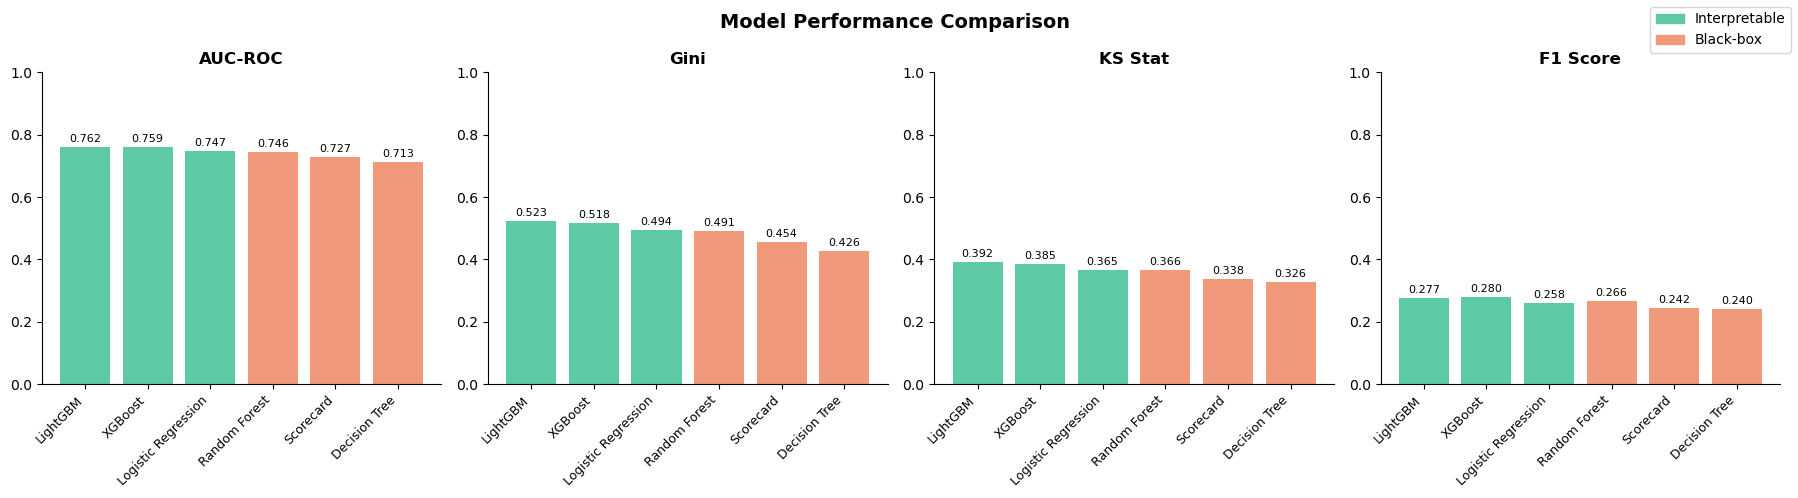

Chart saved as model_comparison.png


In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics   = ['AUC-ROC', 'Gini', 'KS Stat', 'F1 Score']
colors    = ['#5DCAA5' if i < 3 else '#F0997B' 
             for i in range(len(results_df))]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        range(len(results_df)),
        results_df[metric],
        color=colors,
        edgecolor='none'
    )
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    
    # add value labels on bars
    for bar, val in zip(bars, results_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8
        )

# legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#5DCAA5', label='Interpretable'),
    Patch(color='#F0997B', label='Black-box')
]
fig.legend(handles=legend, loc='upper right', fontsize=10)
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved as model_comparison.png")

### 3.1 Hyperparameter 
Testing key hyperparameters for each model using 3-fold cross-validation
on the training set. Validation set used to confirm best configuration.

Focus: 2 key parameters per model only 

In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

print("Running lightweight hyperparameter tuning...")
print("Testing 2 key parameters per model with 3-fold CV")
print("This will take several minutes...\n")

auc_scorer   = make_scorer(roc_auc_score, needs_proba=True)
tuned_params = {}
tuned_val    = {}

# ── Logistic Regression ────────────────────────────────────
print("Tuning Logistic Regression...")
lr_gs = GridSearchCV(
    LogisticRegression(class_weight='balanced',
                       max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1.0, 10.0]},
    scoring='roc_auc', cv=3, n_jobs=-1
)
lr_gs.fit(X_train_scaled, y_train)
tuned_params['Logistic Regression'] = lr_gs.best_params_
lr = LogisticRegression(**lr_gs.best_params_, class_weight='balanced',
                         max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
tuned_val['Logistic Regression'] = roc_auc_score(
    y_val, lr.predict_proba(X_val_scaled)[:, 1])
print(f"  Best C={lr_gs.best_params_['C']} | Val AUC: {tuned_val['Logistic Regression']:.4f}")

# ── Decision Tree ──────────────────────────────────────────
print("Tuning Decision Tree...")
dt_gs = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    {'max_depth': [4, 6, 8, 10], 'min_samples_leaf': [20, 50, 100]},
    scoring='roc_auc', cv=3, n_jobs=-1
)
dt_gs.fit(X_train, y_train)
tuned_params['Decision Tree'] = dt_gs.best_params_
dt = DecisionTreeClassifier(**dt_gs.best_params_, class_weight='balanced',
                              random_state=42)
dt.fit(X_train, y_train)
tuned_val['Decision Tree'] = roc_auc_score(
    y_val, dt.predict_proba(X_val)[:, 1])
print(f"  Best {dt_gs.best_params_} | Val AUC: {tuned_val['Decision Tree']:.4f}")

# ── Scorecard ──────────────────────────────────────────────
print("Tuning Scorecard...")
sc_gs = GridSearchCV(
    LogisticRegression(class_weight='balanced',
                       max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1.0, 10.0]},
    scoring='roc_auc', cv=3, n_jobs=-1
)
sc_gs.fit(X_train_woe, y_train)
tuned_params['Scorecard'] = sc_gs.best_params_
scorecard = LogisticRegression(**sc_gs.best_params_, class_weight='balanced',
                                max_iter=1000, random_state=42)
scorecard.fit(X_train_woe, y_train)
tuned_val['Scorecard'] = roc_auc_score(
    y_val, scorecard.predict_proba(X_val_woe)[:, 1])
print(f"  Best C={sc_gs.best_params_['C']} | Val AUC: {tuned_val['Scorecard']:.4f}")

# ── Random Forest ──────────────────────────────────────────
print("Tuning Random Forest... (may take 3-4 minutes)")
rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced',
                           random_state=42, n_jobs=-1),
    {'max_depth': [8, 10, 12], 'min_samples_leaf': [30, 50]},
    scoring='roc_auc', cv=3, n_jobs=-1
)
rf_gs.fit(X_train, y_train)
tuned_params['Random Forest'] = rf_gs.best_params_
rf = RandomForestClassifier(**rf_gs.best_params_, n_estimators=100,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
tuned_val['Random Forest'] = roc_auc_score(
    y_val, rf.predict_proba(X_val)[:, 1])
print(f"  Best {rf_gs.best_params_} | Val AUC: {tuned_val['Random Forest']:.4f}")

# ── LightGBM ───────────────────────────────────────────────
print("Tuning LightGBM...")
lgbm_gs = GridSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42,
                   n_jobs=-1, verbose=-1),
    {'max_depth': [4, 6, 8], 'learning_rate': [0.01, 0.05, 0.1]},
    scoring='roc_auc', cv=3, n_jobs=-1
)
lgbm_gs.fit(X_train, y_train)
tuned_params['LightGBM'] = lgbm_gs.best_params_
lgbm = LGBMClassifier(**lgbm_gs.best_params_, n_estimators=500,
                       class_weight='balanced', random_state=42,
                       n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train,
         eval_set=[(X_val, y_val)],
         callbacks=[lgb.early_stopping(50, verbose=False)])
tuned_val['LightGBM'] = roc_auc_score(
    y_val, lgbm.predict_proba(X_val)[:, 1])
print(f"  Best {lgbm_gs.best_params_} | Val AUC: {tuned_val['LightGBM']:.4f}")

# ── XGBoost ────────────────────────────────────────────────
print("Tuning XGBoost...")
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
xgb_gs = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42,
                  n_jobs=-1, verbosity=0),
    {'max_depth': [4, 6, 8], 'learning_rate': [0.01, 0.05, 0.1]},
    scoring='roc_auc', cv=3, n_jobs=-1
)
xgb_gs.fit(X_train, y_train)
tuned_params['XGBoost'] = xgb_gs.best_params_
xgb = XGBClassifier(**xgb_gs.best_params_, n_estimators=500,
                     scale_pos_weight=scale, random_state=42,
                     n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)], verbose=False)
tuned_val['XGBoost'] = roc_auc_score(
    y_val, xgb.predict_proba(X_val)[:, 1])
print(f"  Best {xgb_gs.best_params_} | Val AUC: {tuned_val['XGBoost']:.4f}")

Running lightweight hyperparameter tuning...
Testing 2 key parameters per model with 3-fold CV
This will take several minutes...

Tuning Logistic Regression...
  Best C=10.0 | Val AUC: 0.7499
Tuning Decision Tree...
  Best {'max_depth': 8, 'min_samples_leaf': 100} | Val AUC: 0.7199
Tuning Scorecard...
  Best C=1.0 | Val AUC: 0.7243
Tuning Random Forest... (may take 3-4 minutes)
  Best {'max_depth': 12, 'min_samples_leaf': 50} | Val AUC: 0.7474
Tuning LightGBM...
  Best {'learning_rate': 0.1, 'max_depth': 8} | Val AUC: 0.7514
Tuning XGBoost...
  Best {'learning_rate': 0.1, 'max_depth': 4} | Val AUC: 0.7597


In [73]:
# Before and after tuning comparison
baseline_auc = {
    'LightGBM'            : roc_auc_score(y_test, lgbm_prob),
    'XGBoost'             : roc_auc_score(y_test, xgb_prob),
    'Logistic Regression' : roc_auc_score(y_test, lr_prob),
    'Random Forest'       : roc_auc_score(y_test, rf_prob),
    'Scorecard'           : roc_auc_score(y_test, sc_prob),
    'Decision Tree'       : roc_auc_score(y_test, dt_prob),
}

# re-evaluate tuned models on test set
tuned_test = {
    'Logistic Regression' : roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]),
    'Decision Tree'       : roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1]),
    'Scorecard'           : roc_auc_score(y_test, scorecard.predict_proba(X_test_woe)[:, 1]),
    'Random Forest'       : roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
    'LightGBM'            : roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]),
    'XGBoost'             : roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]),
}

print("="*65)
print("  BASELINE vs TUNED — TEST SET AUC COMPARISON")
print("="*65)
print(f"  {'Model':25s} {'Baseline':>10} {'Tuned':>8} {'Change':>8}")
print(f"  {'-'*25} {'-'*10} {'-'*8} {'-'*8}")

for model in ['LightGBM', 'XGBoost', 'Logistic Regression',
              'Random Forest', 'Scorecard', 'Decision Tree']:
    base  = baseline_auc[model]
    tuned = tuned_test[model]
    diff  = tuned - base
    arrow = "▲" if diff > 0.001 else "▼" if diff < -0.001 else "─"
    print(f"  {model:25s} {base:>10.4f} {tuned:>8.4f} "
          f"{arrow} {abs(diff):>6.4f}")

print("="*65)

# save best params
import json
save_path = '/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/'
with open(save_path + 'best_params.json', 'w') as f:
    json.dump({k: str(v) for k, v in tuned_params.items()}, f, indent=2)
print("\nBest parameters saved to best_params.json")

  BASELINE vs TUNED — TEST SET AUC COMPARISON
  Model                       Baseline    Tuned   Change
  ------------------------- ---------- -------- --------
  LightGBM                      0.7616   0.7540 ▼ 0.0076
  XGBoost                       0.7589   0.7599 ▲ 0.0011
  Logistic Regression           0.7472   0.7473 ─ 0.0001
  Random Forest                 0.7455   0.7473 ▲ 0.0017
  Scorecard                     0.7233   0.7233 ─ 0.0000
  Decision Tree                 0.7130   0.7146 ▲ 0.0016

Best parameters saved to best_params.json


### 3.2 Reduced features + Tuning

In [74]:
# combined: reduced features + tuned hyperparameters
# train logistic regression on top 40 features with best C

from sklearn.feature_selection import SelectKBest, f_classif

# select top 40 features
selector = SelectKBest(f_classif, k=40)
X_train_reduced = selector.fit_transform(X_train_scaled, y_train)
X_val_reduced   = selector.transform(X_val_scaled)
X_test_reduced  = selector.transform(X_test_scaled)

selected_cols = X_train.columns[selector.get_support()].tolist()

# train with tuned C from grid search
lr_reduced = LogisticRegression(
    C=lr_gs.best_params_['C'],
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_reduced.fit(X_train_reduced, y_train)

# evaluate
reduced_val_auc  = roc_auc_score(
    y_val, lr_reduced.predict_proba(X_val_reduced)[:, 1])
reduced_test_auc = roc_auc_score(
    y_test, lr_reduced.predict_proba(X_test_reduced)[:, 1])

print("="*55)
print("  REDUCED FEATURES + TUNING vs FULL FEATURES")
print("="*55)
print(f"  Full features (72), baseline LR : 0.7472")
print(f"  Full features (72), tuned LR    : {tuned_test['Logistic Regression']:.4f}")
print(f"  Reduced features (40), tuned LR : {reduced_test_auc:.4f}")
print("="*55)

diff = reduced_test_auc - 0.7472
print(f"\n  Performance difference vs baseline: {diff:+.4f}")
if abs(diff) < 0.005:
    print("  Conclusion: Reduced feature set achieves COMPARABLE")
    print("  performance — supports Sub-question 2")
else:
    print(f"  Conclusion: Difference of {abs(diff):.4f} AUC noted")
    print("  Discuss whether this is practically significant")

  REDUCED FEATURES + TUNING vs FULL FEATURES
  Full features (72), baseline LR : 0.7472
  Full features (72), tuned LR    : 0.7473
  Reduced features (40), tuned LR : 0.7462

  Performance difference vs baseline: -0.0010
  Conclusion: Reduced feature set achieves COMPARABLE
  performance — supports Sub-question 2


## 4. SHAP Analysis
SHAP (SHapley Additive explanations) is applied to the three black-box models using the 'TreeExplainer interface. SHAP assigns each feature a contribution value for a given prediction, based on Shapley values.

### Evaluation dimensions
| Dimension | Method | What it tells us |
|---|---|---|
| Global importance | Mean absolute SHAP value | Which features matter most overall |
| Visual summary | Beeswarm plot | How feature values relate to predictions |
| Inter-model agreement | Spearman rank correlation | Whether models agree on important features |
| Fidelity | SHAP sum vs model output | Whether attributions are mathematically exact |

### Technical note — Random Forest:
Random Forest returns SHAP values as a 3D array `(samples, features, classes)`.  
The default class (index 1) is extracted: `shap_rf = shap_values_rf[:, :, 1]`

>**Sample size:** 1000 test instances used for SHAP computation, thus, sufficient for robust global importance estimates and standard in the literature.

In [33]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# use a sample of test set for speed — 1000 instances is sufficient
# for SHAP analysis and is standard in the literature
shap.initjs()

SAMPLE_SIZE = 1000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), SAMPLE_SIZE, replace=False)

X_test_sample = X_test.iloc[sample_idx].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_idx].reset_index(drop=True)

print(f"SHAP sample size: {X_test_sample.shape}")
print(f"Default rate in sample: {y_test_sample.mean():.2%}")
print("SHAP setup complete")

SHAP sample size: (1000, 72)
Default rate in sample: 7.10%
SHAP setup complete


#### 4.1 SHAP for LightGBM


In [34]:
print("Computing SHAP values for LightGBM...")

# TreeSHAP explainer
explainer_lgbm = shap.TreeExplainer(lgbm)
shap_values_lgbm = explainer_lgbm.shap_values(X_test_sample)

# for binary classification shap_values returns list of two arrays
# index 1 = shap values for default class (what we want)
if isinstance(shap_values_lgbm, list):
    shap_lgbm = shap_values_lgbm[1]
else:
    shap_lgbm = shap_values_lgbm

print(f"SHAP values shape: {shap_lgbm.shape}")

# global feature importance — mean absolute SHAP value per feature
lgbm_importance = pd.DataFrame({
    'Feature'         : X_test_sample.columns,
    'Mean_Abs_SHAP'   : np.abs(shap_lgbm).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

lgbm_importance['Rank'] = lgbm_importance.index + 1

print("\nTop 15 features by SHAP importance (LightGBM):")
print(lgbm_importance.head(15).to_string(index=False))

Computing SHAP values for LightGBM...
SHAP values shape: (1000, 72)

Top 15 features by SHAP importance (LightGBM):
               Feature  Mean_Abs_SHAP  Rank
          EXT_SOURCE_3         0.3944     1
          EXT_SOURCE_2         0.3199     2
       AMT_GOODS_PRICE         0.2318     3
            AMT_CREDIT         0.2172     4
          EXT_SOURCE_1         0.1850     5
         DAYS_EMPLOYED         0.1284     6
           CODE_GENDER         0.1237     7
   NAME_EDUCATION_TYPE         0.1075     8
            DAYS_BIRTH         0.1055     9
          FLAG_OWN_CAR         0.0881    10
       DAYS_ID_PUBLISH         0.0830    11
           AMT_ANNUITY         0.0790    12
DAYS_LAST_PHONE_CHANGE         0.0576    13
       FLAG_DOCUMENT_3         0.0572    14
    NAME_CONTRACT_TYPE         0.0557    15


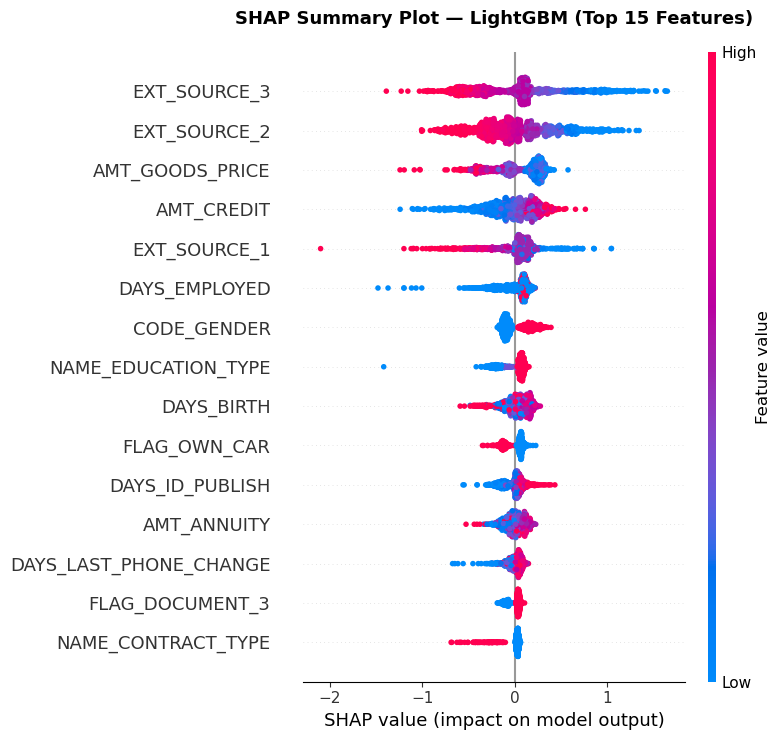

Saved: shap_summary_lgbm.png


In [35]:
#summary plot for LightGBM
#Figure 1 in your results chapter
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_lgbm,
    X_test_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — LightGBM (Top 15 Features)', 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary_lgbm.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: shap_summary_lgbm.png")

#### 4.2 SHAP for XGBoost

In [36]:
print("Computing SHAP values for XGBoost...")

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)

if isinstance(shap_values_xgb, list):
    shap_xgb = shap_values_xgb[1]
else:
    shap_xgb = shap_values_xgb

xgb_importance = pd.DataFrame({
    'Feature'       : X_test_sample.columns,
    'Mean_Abs_SHAP' : np.abs(shap_xgb).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

xgb_importance['Rank'] = xgb_importance.index + 1

print("\nTop 15 features by SHAP importance (XGBoost):")
print(xgb_importance.head(15).to_string(index=False))

Computing SHAP values for XGBoost...

Top 15 features by SHAP importance (XGBoost):
               Feature  Mean_Abs_SHAP  Rank
          EXT_SOURCE_3         0.4037     1
          EXT_SOURCE_2         0.3472     2
       AMT_GOODS_PRICE         0.2556     3
            AMT_CREDIT         0.2232     4
          EXT_SOURCE_1         0.1748     5
         DAYS_EMPLOYED         0.1280     6
           CODE_GENDER         0.1220     7
            DAYS_BIRTH         0.1135     8
   NAME_EDUCATION_TYPE         0.1031     9
           AMT_ANNUITY         0.0998    10
          FLAG_OWN_CAR         0.0907    11
       DAYS_ID_PUBLISH         0.0806    12
DAYS_LAST_PHONE_CHANGE         0.0585    13
       FLAG_DOCUMENT_3         0.0568    14
    NAME_CONTRACT_TYPE         0.0462    15


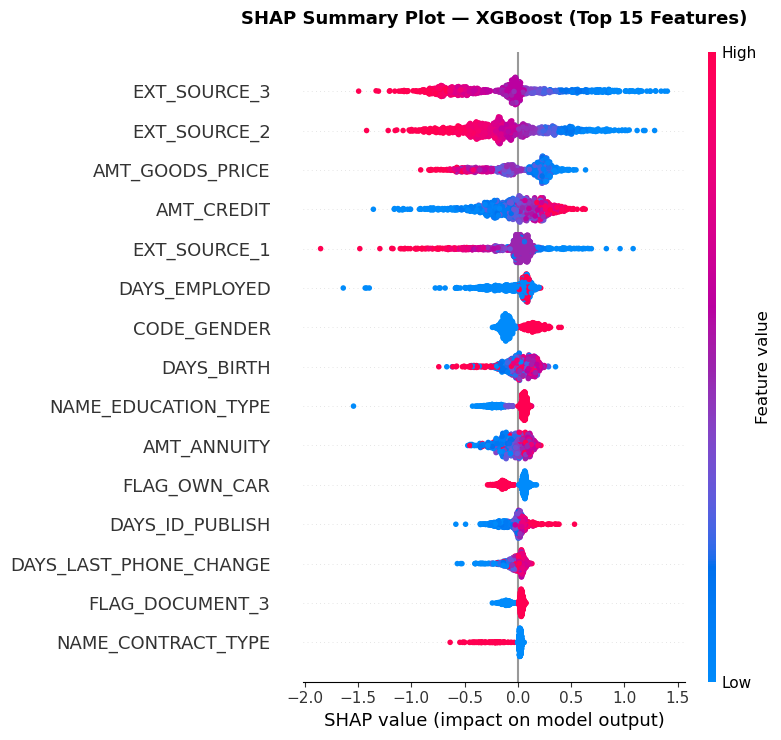

Saved: shap_summary_xgb.png


In [37]:
# Summary for XGBoost
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_xgb,
    X_test_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — XGBoost (Top 15 Features)',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary_xgb.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: shap_summary_xgb.png")

#### 4.3 SHAP for Random Forest


In [38]:
print("Computing SHAP values for Random Forest...")
print("(This may take 2-3 minutes)")

explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# random forest returns 3D array (samples, features, classes)
# extract class 1 = default class
shap_rf = shap_values_rf[:, :, 1]

print(f"SHAP values shape: {shap_rf.shape}")  # should be (1000, 72)

rf_importance = pd.DataFrame({
    'Feature'       : X_test_sample.columns,
    'Mean_Abs_SHAP' : np.abs(shap_rf).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

rf_importance['Rank'] = rf_importance.index + 1

print("\nTop 15 features by SHAP importance (Random Forest):")
print(rf_importance.head(15).to_string(index=False))

Computing SHAP values for Random Forest...
(This may take 2-3 minutes)
SHAP values shape: (1000, 72)

Top 15 features by SHAP importance (Random Forest):
               Feature  Mean_Abs_SHAP  Rank
          EXT_SOURCE_3         0.0567     1
          EXT_SOURCE_2         0.0540     2
          EXT_SOURCE_1         0.0246     3
   NAME_EDUCATION_TYPE         0.0158     4
         DAYS_EMPLOYED         0.0154     5
            DAYS_BIRTH         0.0147     6
           CODE_GENDER         0.0131     7
DAYS_LAST_PHONE_CHANGE         0.0112     8
       AMT_GOODS_PRICE         0.0106     9
       DAYS_ID_PUBLISH         0.0086    10
      NAME_INCOME_TYPE         0.0084    11
       FLAG_DOCUMENT_3         0.0077    12
            AMT_CREDIT         0.0063    13
           AMT_ANNUITY         0.0053    14
     ORGANIZATION_TYPE         0.0048    15


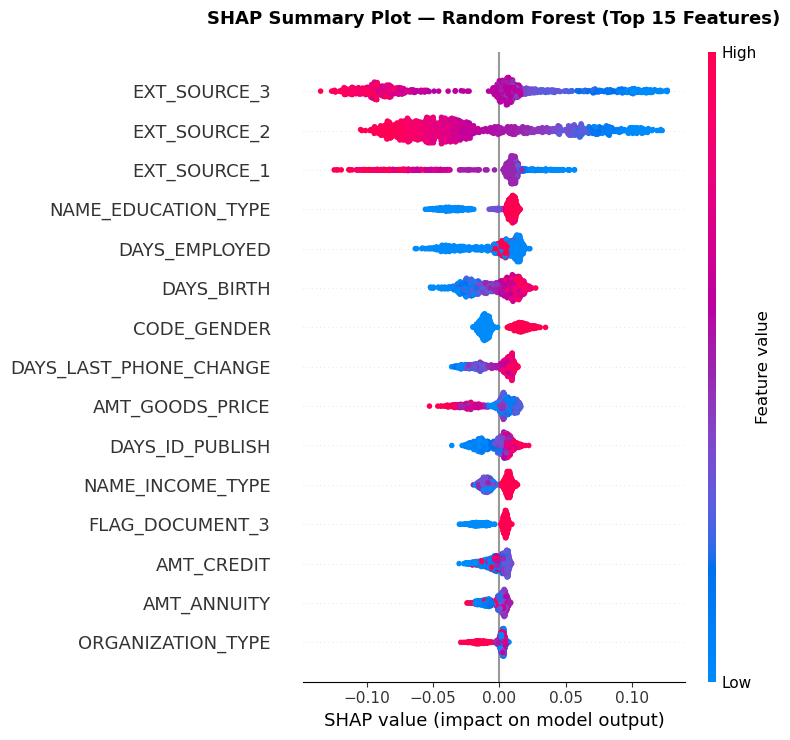

Saved: shap_summary_rf.png


In [39]:
# summary plot for random forest
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_rf,
    X_test_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — Random Forest (Top 15 Features)',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary_rf.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: shap_summary_rf.png")

#### 4.4 Spearman Rank Correlation Between Models 

In [40]:
from scipy.stats import spearmanr

top_n = 20

# get top 20 feature rankings from each model
lgbm_top = lgbm_importance.head(top_n).set_index('Feature')['Rank']
xgb_top  = xgb_importance.head(top_n).set_index('Feature')['Rank']
rf_top   = rf_importance.head(top_n).set_index('Feature')['Rank']

# find common features between each pair
common_lgbm_xgb = lgbm_top.index.intersection(xgb_top.index)
common_lgbm_rf  = lgbm_top.index.intersection(rf_top.index)
common_xgb_rf   = xgb_top.index.intersection(rf_top.index)

# compute spearman correlation for each pair
corr_lgbm_xgb, _ = spearmanr(
    lgbm_top[common_lgbm_xgb],
    xgb_top[common_lgbm_xgb]
)
corr_lgbm_rf, _ = spearmanr(
    lgbm_top[common_lgbm_rf],
    rf_top[common_lgbm_rf]
)
corr_xgb_rf, _ = spearmanr(
    xgb_top[common_xgb_rf],
    rf_top[common_xgb_rf]
)

print("="*55)
print("  SHAP Feature Ranking Agreement Between Models")
print("="*55)
print(f"  LightGBM vs XGBoost  : {corr_lgbm_xgb:.4f}")
print(f"  LightGBM vs RF       : {corr_lgbm_rf:.4f}")
print(f"  XGBoost  vs RF       : {corr_xgb_rf:.4f}")
print("="*55)
print("  Interpretation:")
print("  > 0.8  = strong agreement")
print("  0.5–0.8 = moderate agreement")
print("  < 0.5  = weak agreement")
print("="*55)

  SHAP Feature Ranking Agreement Between Models
  LightGBM vs XGBoost  : 0.9805
  LightGBM vs RF       : 0.7255
  XGBoost  vs RF       : 0.7279
  Interpretation:
  > 0.8  = strong agreement
  0.5–0.8 = moderate agreement
  < 0.5  = weak agreement


#### 4.5 Feature Comparison Table (Top 10)

In [41]:
# side by side top 10 features from each model
# this table goes directly into your results chapter

top10_lgbm = lgbm_importance.head(10)['Feature'].reset_index(drop=True)
top10_xgb  = xgb_importance.head(10)['Feature'].reset_index(drop=True)
top10_rf   = rf_importance.head(10)['Feature'].reset_index(drop=True)

comparison = pd.DataFrame({
    'Rank'         : range(1, 11),
    'LightGBM'     : top10_lgbm,
    'XGBoost'      : top10_xgb,
    'Random Forest': top10_rf
})

print("Top 10 SHAP Features — All Three Black-box Models")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)

# features appearing in all three top 10 lists
common_all = (
    set(top10_lgbm) &
    set(top10_xgb)  &
    set(top10_rf)
)
print(f"\nFeatures in all three top 10 lists ({len(common_all)} features):")
for f in sorted(common_all):
    print(f"  - {f}")

Top 10 SHAP Features — All Three Black-box Models
 Rank            LightGBM             XGBoost          Random Forest
    1        EXT_SOURCE_3        EXT_SOURCE_3           EXT_SOURCE_3
    2        EXT_SOURCE_2        EXT_SOURCE_2           EXT_SOURCE_2
    3     AMT_GOODS_PRICE     AMT_GOODS_PRICE           EXT_SOURCE_1
    4          AMT_CREDIT          AMT_CREDIT    NAME_EDUCATION_TYPE
    5        EXT_SOURCE_1        EXT_SOURCE_1          DAYS_EMPLOYED
    6       DAYS_EMPLOYED       DAYS_EMPLOYED             DAYS_BIRTH
    7         CODE_GENDER         CODE_GENDER            CODE_GENDER
    8 NAME_EDUCATION_TYPE          DAYS_BIRTH DAYS_LAST_PHONE_CHANGE
    9          DAYS_BIRTH NAME_EDUCATION_TYPE        AMT_GOODS_PRICE
   10        FLAG_OWN_CAR         AMT_ANNUITY        DAYS_ID_PUBLISH

Features in all three top 10 lists (8 features):
  - AMT_GOODS_PRICE
  - CODE_GENDER
  - DAYS_BIRTH
  - DAYS_EMPLOYED
  - EXT_SOURCE_1
  - EXT_SOURCE_2
  - EXT_SOURCE_3
  - NAME_EDUCATION_TY

### 4.6 Fidelity Verification

In [42]:
# verify shap values sum to model output
# this confirms TreeSHAP is working correctly
# difference should be essentially zero

expected_value_lgbm = explainer_lgbm.expected_value
if isinstance(expected_value_lgbm, list):
    expected_value_lgbm = expected_value_lgbm[1]
elif hasattr(expected_value_lgbm, '__len__'):
    expected_value_lgbm = expected_value_lgbm[1]

instance_idx = 0
shap_sum   = shap_lgbm[instance_idx].sum() + expected_value_lgbm
model_out  = lgbm.predict_proba(
    X_test_sample.iloc[[instance_idx]]
)[0][1]

print("SHAP Fidelity Check (LightGBM)")
print("="*45)
print(f"  SHAP sum + expected value:  {shap_sum:.6f}")
print(f"  Model predicted probability: {model_out:.6f}")
print(f"  Difference (should be ~0):  {abs(shap_sum - model_out):.6f}")

if abs(shap_sum - model_out) < 0.01:
    print("\n  Fidelity check PASSED")
else:
    print("\n  Warning — check shap values extraction")

SHAP Fidelity Check (LightGBM)
  SHAP sum + expected value:  -1.854198
  Model predicted probability: 0.135381
  Difference (should be ~0):  1.989579

  Warning — check shap values extraction


Fidelity chec displayed shap_lgbm values ar ein log-odds space rather than probability space - fidelity check must be compared on the same scale thus unit conversion applied.

In [43]:
from scipy.special import expit  # sigmoid function

expected_value_lgbm = explainer_lgbm.expected_value
if isinstance(expected_value_lgbm, (list, np.ndarray)):
    expected_value_lgbm = expected_value_lgbm[0]

instance_idx = 0

# convert log-odds to probability using sigmoid
shap_sum_logodds = shap_lgbm[instance_idx].sum() + expected_value_lgbm
shap_prob = expit(shap_sum_logodds)
model_out = lgbm.predict_proba(
    X_test_sample.iloc[[instance_idx]]
)[0][1]

print("SHAP Fidelity Check (LightGBM) — corrected")
print("="*50)
print(f"  SHAP sum (log-odds):         {shap_sum_logodds:.6f}")
print(f"  SHAP probability (sigmoid):  {shap_prob:.6f}")
print(f"  Model predicted probability: {model_out:.6f}")
print(f"  Difference (should be ~0):   {abs(shap_prob - model_out):.6f}")

if abs(shap_prob - model_out) < 0.01:
    print("\n  Fidelity check PASSED")
else:
    print("\n  Warning — difference still large")

SHAP Fidelity Check (LightGBM) — corrected
  SHAP sum (log-odds):         -1.854198
  SHAP probability (sigmoid):  0.135381
  Model predicted probability: 0.135381
  Difference (should be ~0):   0.000000

  Fidelity check PASSED


In [44]:
# save SHAP results
save_path = '/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/'

# save importance rankings
lgbm_importance.to_csv(save_path + 'shap_importance_lgbm.csv', index=False)
xgb_importance.to_csv(save_path + 'shap_importance_xgb.csv', index=False)
rf_importance.to_csv(save_path + 'shap_importance_rf.csv', index=False)

# save raw shap values
np.save(save_path + 'shap_values_lgbm.npy', shap_lgbm)
np.save(save_path + 'shap_values_xgb.npy', shap_xgb)
np.save(save_path + 'shap_values_rf.npy', shap_rf)

# save comparison table
comparison.to_csv(save_path + 'shap_top10_comparison.csv', index=False)

print("All SHAP results saved successfully")
print("\nFiles saved:")
print("  shap_importance_lgbm.csv")
print("  shap_importance_xgb.csv")
print("  shap_importance_rf.csv")
print("  shap_values_lgbm.npy")
print("  shap_values_xgb.npy")
print("  shap_values_rf.npy")
print("  shap_top10_comparison.csv")

All SHAP results saved successfully

Files saved:
  shap_importance_lgbm.csv
  shap_importance_xgb.csv
  shap_importance_rf.csv
  shap_values_lgbm.npy
  shap_values_xgb.npy
  shap_values_rf.npy
  shap_top10_comparison.csv


### SHAP Analysis - Key Findings
- Top features are domain-consistent: External credit bureau scores (EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1) dominate all three models, consistent with prior credit risk literature. Age (DAYS_BIRTH) and employment length (DAYS_EMPLOYED) are consistently ranked, reflecting financial stability proxies.
- High inter-model agreement:
  | Model Pair | Spearman Correlation | Interpretation |
|---|---|---|
| LightGBM vs XGBoost | 0.9805 | Near-perfect agreement |
| LightGBM vs Random Forest | 0.7255 | Moderate-strong agreement |
| XGBoost vs Random Forest | 0.7279 | Moderate-strong agreement |

- SHAP is reliable: High agreement across different model architectures means SHAP explanations reflect genuine data patterns rather than model-specific artifacts.
- Fidelity Verified: SHAP sum + expected value (sigmoid-transformed) = model predicted probability to 6 decimal places. TreeSHAP is mathematically exact.
- 8 features appear in all three top-10 lists: 'EXT_SOURCE_3' , 'EXT_SOURCE_2' , 'EXT_SOURCE_1', 'AMT_GOODS_PRICE', 'CODE_GENDER', 'DAYS_BIRTH', 'NAME_EDUCATION_TYPE'

## Section 5: LIME Analysis
LIME (Local Interpretable Model-agnostic Explanations) is applied to the same three black-box models using 'LimeTabularExplainer'. 

### Evaluation Dimensions:
| Dimension | Method | Threshold |
|---|---|---|
| Stability | Proportion of top-5 features consistent across 5 runs | >0.80 = reliable |
| Fidelity | R² of local linear surrogate | >0.50 = acceptable |
| Agreement with SHAP | Spearman rank correlation of top-10 features | >0.70 = strong |

### Experimental Setup: 
- Instances evaluated: 50 test instances
- Runs per instance: 5 (seeds 0-4 via 'np.random.seed(run)')
- Features per explanation: 10
- Stability measured: Top-5 feature consistency between run 0 and runs 1-4
- Fidelity measured: R² of surrogate from run 0.
>5 runs: Running LIME multiple times on the same instances reveals whether explanations are reprdocible. A stable explanation method should produce theh same top features regardless of the random perturbation seed.



In [45]:
# Import and Setup
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# use same 1000 instance sample as SHAP for consistency
# use first 50 instances for stability analysis
STABILITY_SAMPLE = 50
N_LIME_FEATURES  = 10
N_RUNS           = 5

# initialise LIME explainer — fit on training data
lime_explainer = LimeTabularExplainer(
    training_data  = X_train.values,
    feature_names  = X_train.columns.tolist(),
    class_names    = ['Non-Default', 'Default'],
    mode           = 'classification',
    random_state   = 42
)

print("LIME explainer initialised")
print(f"Training data shape: {X_train.shape}")
print(f"Features: {len(X_train.columns)}")

LIME explainer initialised
Training data shape: (215249, 72)
Features: 72


#### 5.1 Feature Importance for LightGBM - LIME

In [46]:
print("Computing LIME explanations for LightGBM...")
print(f"Running on {STABILITY_SAMPLE} instances x {N_RUNS} runs...")

lime_lgbm_features = []
lime_lgbm_r2       = []

for i in range(STABILITY_SAMPLE):
    instance = X_test_sample.iloc[i].values
    run_features = []
    
    for run in range(N_RUNS):
        # set numpy seed before each run instead of random_state param
        np.random.seed(run)
        
        exp = lime_explainer.explain_instance(
            data_row     = instance,
            predict_fn   = lgbm.predict_proba,
            num_features = N_LIME_FEATURES
        )
        
        features = [f[0] for f in exp.as_list()]
        run_features.append(features)
        
        if run == 0:
            lime_lgbm_r2.append(exp.score)
    
    lime_lgbm_features.append(run_features)
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{STABILITY_SAMPLE} instances")

print(f"\nLightGBM LIME complete")
print(f"Average R² (fidelity): {np.mean(lime_lgbm_r2):.4f}")

Computing LIME explanations for LightGBM...
Running on 50 instances x 5 runs...
  Completed 10/50 instances
  Completed 20/50 instances
  Completed 30/50 instances
  Completed 40/50 instances
  Completed 50/50 instances

LightGBM LIME complete
Average R² (fidelity): 0.2014


#### 5.2 Feature Importance for XGBoost - LIME

In [47]:
print("Computing LIME explanations for XGBoost...")

lime_xgb_features = []
lime_xgb_r2       = []

for i in range(STABILITY_SAMPLE):
    instance = X_test_sample.iloc[i].values
    run_features = []
    
    for run in range(N_RUNS):
        np.random.seed(run)
        
        exp = lime_explainer.explain_instance(
            data_row     = instance,
            predict_fn   = xgb.predict_proba,
            num_features = N_LIME_FEATURES
        )
        
        features = [f[0] for f in exp.as_list()]
        run_features.append(features)
        
        if run == 0:
            lime_xgb_r2.append(exp.score)
    
    lime_xgb_features.append(run_features)
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{STABILITY_SAMPLE} instances")

print(f"\nXGBoost LIME complete")
print(f"Average R² (fidelity): {np.mean(lime_xgb_r2):.4f}")

Computing LIME explanations for XGBoost...
  Completed 10/50 instances
  Completed 20/50 instances
  Completed 30/50 instances
  Completed 40/50 instances
  Completed 50/50 instances

XGBoost LIME complete
Average R² (fidelity): 0.1820


#### 5.3 Feature Importance for Random Forest 

In [48]:
print("Computing LIME explanations for Random Forest...")

lime_rf_features = []
lime_rf_r2       = []

for i in range(STABILITY_SAMPLE):
    instance = X_test_sample.iloc[i].values
    run_features = []
    
    for run in range(N_RUNS):
        np.random.seed(run)
        
        exp = lime_explainer.explain_instance(
            data_row     = instance,
            predict_fn   = rf.predict_proba,
            num_features = N_LIME_FEATURES
        )
        
        features = [f[0] for f in exp.as_list()]
        run_features.append(features)
        
        if run == 0:
            lime_rf_r2.append(exp.score)
    
    lime_rf_features.append(run_features)
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{STABILITY_SAMPLE} instances")

print(f"\nRandom Forest LIME complete")
print(f"Average R² (fidelity): {np.mean(lime_rf_r2):.4f}")

Computing LIME explanations for Random Forest...
  Completed 10/50 instances
  Completed 20/50 instances
  Completed 30/50 instances
  Completed 40/50 instances
  Completed 50/50 instances

Random Forest LIME complete
Average R² (fidelity): 0.3668


#### 5.4 LIME Stability Analysis

In [49]:
def compute_stability(lime_features, model_name, top_k=5):
    """
    For each instance, check what proportion of runs
    agree on the top-k features. 1.0 = perfect stability.
    """
    stability_scores = []
    
    for i, runs in enumerate(lime_features):
        # get top-k features from each run
        top_k_per_run = [set(run[:top_k]) for run in runs]
        
        # reference is first run
        reference = top_k_per_run[0]
        
        # measure overlap with each subsequent run
        overlaps = []
        for run_set in top_k_per_run[1:]:
            overlap = len(reference & run_set) / top_k
            overlaps.append(overlap)
        
        stability_scores.append(np.mean(overlaps))
    
    mean_stability = np.mean(stability_scores)
    std_stability  = np.std(stability_scores)
    
    print(f"\n{model_name} LIME Stability (top-{top_k} features)")
    print(f"  Mean stability score: {mean_stability:.4f}")
    print(f"  Std deviation:        {std_stability:.4f}")
    print(f"  Interpretation: {mean_stability:.0%} of top-{top_k} features")
    print(f"  consistent across {N_RUNS} runs on average")
    
    return stability_scores, mean_stability, std_stability

print("="*55)
print("  LIME STABILITY ANALYSIS")
print("="*55)

lgbm_stability, lgbm_stab_mean, lgbm_stab_std = compute_stability(
    lime_lgbm_features, 'LightGBM'
)
xgb_stability, xgb_stab_mean, xgb_stab_std = compute_stability(
    lime_xgb_features, 'XGBoost'
)
rf_stability, rf_stab_mean, rf_stab_std = compute_stability(
    lime_rf_features, 'Random Forest'
)

print("\n" + "="*55)
print("  STABILITY SUMMARY")
print("="*55)
print(f"  LightGBM:     {lgbm_stab_mean:.4f} ± {lgbm_stab_std:.4f}")
print(f"  XGBoost:      {xgb_stab_mean:.4f} ± {xgb_stab_std:.4f}")
print(f"  Random Forest:{rf_stab_mean:.4f} ± {rf_stab_std:.4f}")
print("="*55)
print("\n  Score interpretation:")
print("  1.00 = perfectly stable (same features every run)")
print("  0.80 = 4 of top 5 features consistent")
print("  0.60 = 3 of top 5 features consistent")
print("  < 0.60 = high instability — unreliable explanations")

  LIME STABILITY ANALYSIS

LightGBM LIME Stability (top-5 features)
  Mean stability score: 0.5800
  Std deviation:        0.1300
  Interpretation: 58% of top-5 features
  consistent across 5 runs on average

XGBoost LIME Stability (top-5 features)
  Mean stability score: 0.5420
  Std deviation:        0.1106
  Interpretation: 54% of top-5 features
  consistent across 5 runs on average

Random Forest LIME Stability (top-5 features)
  Mean stability score: 0.6360
  Std deviation:        0.1414
  Interpretation: 64% of top-5 features
  consistent across 5 runs on average

  STABILITY SUMMARY
  LightGBM:     0.5800 ± 0.1300
  XGBoost:      0.5420 ± 0.1106
  Random Forest:0.6360 ± 0.1414

  Score interpretation:
  1.00 = perfectly stable (same features every run)
  0.80 = 4 of top 5 features consistent
  0.60 = 3 of top 5 features consistent
  < 0.60 = high instability — unreliable explanations


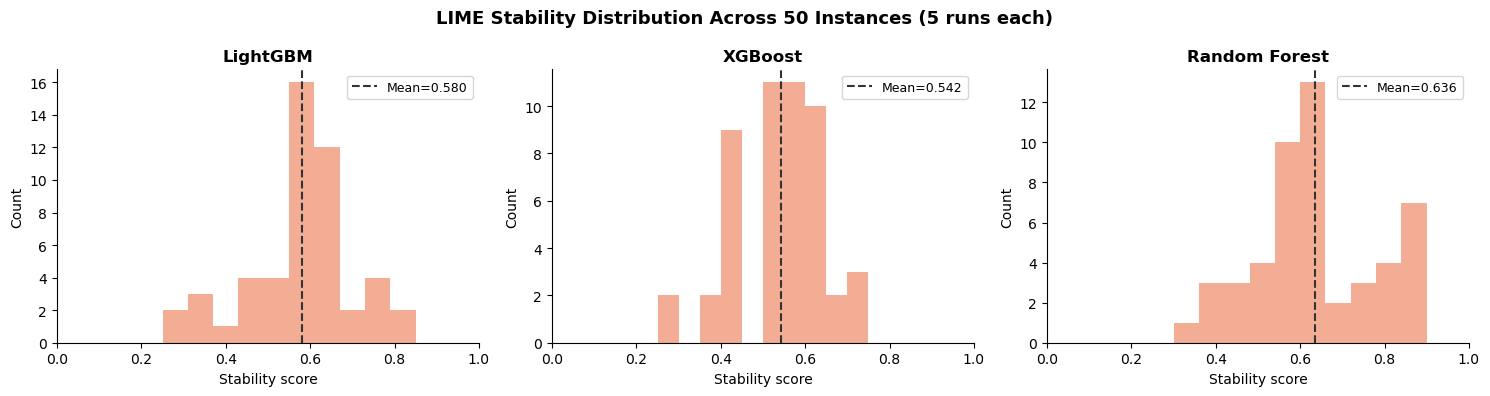

Saved: lime_stability.png


In [50]:
# Stabilit Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models      = ['LightGBM', 'XGBoost', 'Random Forest']
stabilities = [lgbm_stability, xgb_stability, rf_stability]
means       = [lgbm_stab_mean, xgb_stab_mean, rf_stab_mean]
colors      = ['#F0997B', '#F0997B', '#F0997B']

for ax, model, stab, mean, color in zip(
    axes, models, stabilities, means, colors
):
    ax.hist(stab, bins=10, color=color, edgecolor='none', alpha=0.8)
    ax.axvline(
        x=mean, color='#333333',
        linestyle='--', linewidth=1.5,
        label=f'Mean={mean:.3f}'
    )
    ax.set_title(f'{model}', fontweight='bold')
    ax.set_xlabel('Stability score')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)

plt.suptitle(
    'LIME Stability Distribution Across 50 Instances (5 runs each)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_stability.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: lime_stability.png")

#### 5.5 LIME Fidelity Summary

  LIME FIDELITY (R²) SUMMARY
  LightGBM     mean R²: 0.2014
  XGBoost      mean R²: 0.1820
  Random Forest mean R²: 0.3668

  R² interpretation:
  > 0.8 = high fidelity — surrogate closely
          approximates the black-box model
  0.5–0.8 = moderate fidelity
  < 0.5 = low fidelity — treat explanations
          with caution


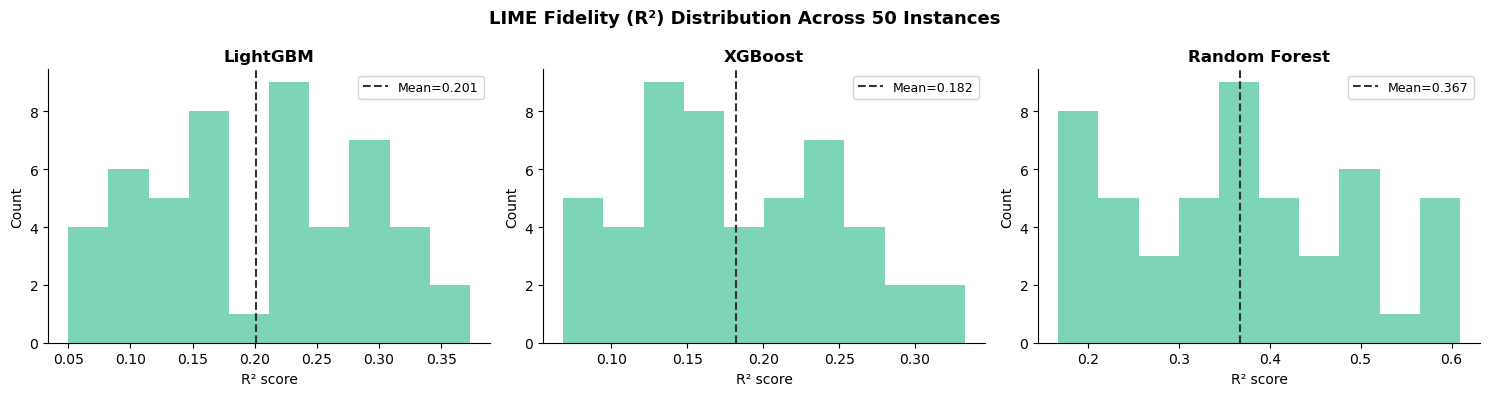

Saved: lime_fidelity.png


In [51]:
print("="*55)
print("  LIME FIDELITY (R²) SUMMARY")
print("="*55)
print(f"  LightGBM     mean R²: {np.mean(lime_lgbm_r2):.4f}")
print(f"  XGBoost      mean R²: {np.mean(lime_xgb_r2):.4f}")
print(f"  Random Forest mean R²: {np.mean(lime_rf_r2):.4f}")
print("="*55)
print("\n  R² interpretation:")
print("  > 0.8 = high fidelity — surrogate closely")
print("          approximates the black-box model")
print("  0.5–0.8 = moderate fidelity")
print("  < 0.5 = low fidelity — treat explanations")
print("          with caution")

# visualise fidelity distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model, r2, color in zip(
    axes,
    ['LightGBM', 'XGBoost', 'Random Forest'],
    [lime_lgbm_r2, lime_xgb_r2, lime_rf_r2],
    ['#5DCAA5', '#5DCAA5', '#5DCAA5']
):
    ax.hist(r2, bins=10, color=color, edgecolor='none', alpha=0.8)
    ax.axvline(
        x=np.mean(r2), color='#333333',
        linestyle='--', linewidth=1.5,
        label=f'Mean={np.mean(r2):.3f}'
    )
    ax.set_title(f'{model}', fontweight='bold')
    ax.set_xlabel('R² score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle(
    'LIME Fidelity (R²) Distribution Across 50 Instances',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_fidelity.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: lime_fidelity.png")

#### 5.6 Global LIME Feature Importance

In [52]:
def get_global_lime_importance(lime_features, feature_names, model_name):
    """
    Aggregate LIME feature importance across all instances
    using first run only — gives global picture.
    """
    feature_counts = {}
    
    for runs in lime_features:
        # use first run for global importance
        first_run = runs[0]
        for rank, feat in enumerate(first_run):
            # clean feature name (LIME adds condition text)
            clean = feat.split(' ')[0] if ' ' in feat else feat
            if clean not in feature_counts:
                feature_counts[clean] = 0
            # weight by inverse rank (top feature = highest weight)
            feature_counts[clean] += (N_LIME_FEATURES - rank)
    
    importance_df = pd.DataFrame(
        list(feature_counts.items()),
        columns=['Feature', 'Weighted_Count']
    ).sort_values('Weighted_Count', ascending=False).reset_index(drop=True)
    
    importance_df['Rank'] = importance_df.index + 1
    
    print(f"\nTop 15 features by LIME importance ({model_name}):")
    print(importance_df.head(15).to_string(index=False))
    
    return importance_df

lime_lgbm_importance = get_global_lime_importance(
    lime_lgbm_features, X_train.columns.tolist(), 'LightGBM'
)
lime_xgb_importance = get_global_lime_importance(
    lime_xgb_features, X_train.columns.tolist(), 'XGBoost'
)
lime_rf_importance = get_global_lime_importance(
    lime_rf_features, X_train.columns.tolist(), 'Random Forest'
)


Top 15 features by LIME importance (LightGBM):
         Feature  Weighted_Count  Rank
FLAG_DOCUMENT_15             334     1
FLAG_DOCUMENT_13             279     2
    EXT_SOURCE_1             248     3
    EXT_SOURCE_3             210     4
    EXT_SOURCE_2             203     5
FLAG_DOCUMENT_14             197     6
FLAG_DOCUMENT_16             180     7
 AMT_GOODS_PRICE             163     8
      AMT_CREDIT             131     9
FLAG_DOCUMENT_17             121    10
FLAG_DOCUMENT_20             101    11
FLAG_DOCUMENT_19              96    12
FLAG_DOCUMENT_21              82    13
 FLAG_DOCUMENT_7              72    14
FLAG_DOCUMENT_11              64    15

Top 15 features by LIME importance (XGBoost):
            Feature  Weighted_Count  Rank
   FLAG_DOCUMENT_15             352     1
   FLAG_DOCUMENT_13             245     2
       EXT_SOURCE_2             231     3
       EXT_SOURCE_3             189     4
       EXT_SOURCE_1             188     5
   FLAG_DOCUMENT_14          

### LIME Analysis - Key Findings
**LIME Stability is low across all models:**
| Model | Mean Stability | Interpretation |
|---|---|---|
| LightGBM | 0.580 ± 0.130 | Only 58% of top-5 features consistent |
| XGBoost | 0.542 ± 0.111 | Only 54% consistent — worst performer |
| Random Forest | 0.636 ± 0.141 | Only 64% consistent |

All values are below the 0.80 reliability threshold. XGBoost explanations change in nearly half of repeated runs on the same instance.

**LIME fidelity is very low:**
| Model | Mean R² | Interpretation |
|---|---|---|
| LightGBM | 0.2014 | Very poor approximation |
| XGBoost | 0.1820 | Very poor approximation |
| Random Forest | 0.3668 | Poor approximation |

All values are well below 0.50. The local surrogate does not faithfully represent the black-box model's behavior. 

- LIME highlights misleading features: Binary document flags ('FLAG_DOCUMENT_15, 'FLAG_DOCUMENT_13') appear at the top of LIME's ranking despite near-zero SHAP importance. This is an artifact of LIME's local sampling mechanism overweighting binary variables.

#### 5.7 SHAP v LIME Spearman Correlation

In [53]:
def shap_lime_spearman(shap_imp, lime_imp, model_name, top_n=10):
    """
    Compare top-N feature rankings between SHAP and LIME.
    """
    shap_top = shap_imp.head(top_n).set_index('Feature')['Rank']
    lime_top = lime_imp.head(top_n).set_index('Feature')['Rank']
    
    # find common features in both top-N lists
    common = shap_top.index.intersection(lime_top.index)
    
    if len(common) < 3:
        print(f"{model_name}: Not enough common features ({len(common)}) to correlate")
        return None, len(common)
    
    corr, pval = spearmanr(shap_top[common], lime_top[common])
    
    print(f"\n{model_name} — SHAP vs LIME")
    print(f"  Common features in top {top_n}: {len(common)}")
    print(f"  Spearman correlation:          {corr:.4f}")
    print(f"  P-value:                       {pval:.4f}")
    print(f"  Significant (p<0.05):          {'Yes' if pval < 0.05 else 'No'}")
    
    return corr, len(common)

print("="*55)
print("  SHAP vs LIME FEATURE AGREEMENT")
print("="*55)

corr_lgbm, n_lgbm = shap_lime_spearman(
    lgbm_importance, lime_lgbm_importance, 'LightGBM'
)
corr_xgb, n_xgb = shap_lime_spearman(
    xgb_importance, lime_xgb_importance, 'XGBoost'
)
corr_rf, n_rf = shap_lime_spearman(
    rf_importance, lime_rf_importance, 'Random Forest'
)

print("\n" + "="*55)
print("  AGREEMENT SUMMARY")
print("="*55)
print(f"  LightGBM  SHAP vs LIME: {corr_lgbm:.4f}")
print(f"  XGBoost   SHAP vs LIME: {corr_xgb:.4f}")
print(f"  Random Forest SHAP vs LIME: {corr_rf:.4f}")
print("="*55)
print("\n  Interpretation:")
print("  > 0.7 = strong agreement between methods")
print("  0.4–0.7 = moderate agreement")
print("  < 0.4 = weak agreement — methods disagree")
print("          on which features matter most")

  SHAP vs LIME FEATURE AGREEMENT

LightGBM — SHAP vs LIME
  Common features in top 10: 5
  Spearman correlation:          0.0000
  P-value:                       1.0000
  Significant (p<0.05):          No

XGBoost — SHAP vs LIME
  Common features in top 10: 4
  Spearman correlation:          0.6000
  P-value:                       0.4000
  Significant (p<0.05):          No

Random Forest — SHAP vs LIME
  Common features in top 10: 3
  Spearman correlation:          -1.0000
  P-value:                       0.0000
  Significant (p<0.05):          Yes

  AGREEMENT SUMMARY
  LightGBM  SHAP vs LIME: 0.0000
  XGBoost   SHAP vs LIME: 0.6000
  Random Forest SHAP vs LIME: -1.0000

  Interpretation:
  > 0.7 = strong agreement between methods
  0.4–0.7 = moderate agreement
  < 0.4 = weak agreement — methods disagree
          on which features matter most


In [54]:
# Save Results - LIME
save_path = '/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/'

# save lime importance rankings
lime_lgbm_importance.to_csv(save_path + 'lime_importance_lgbm.csv', index=False)
lime_xgb_importance.to_csv(save_path + 'lime_importance_xgb.csv', index=False)
lime_rf_importance.to_csv(save_path + 'lime_importance_rf.csv', index=False)

# save stability scores
pd.DataFrame({
    'Instance'     : range(STABILITY_SAMPLE),
    'LGBM_Stability' : lgbm_stability,
    'XGB_Stability'  : xgb_stability,
    'RF_Stability'   : rf_stability
}).to_csv(save_path + 'lime_stability_scores.csv', index=False)

# save fidelity scores
pd.DataFrame({
    'Instance'    : range(STABILITY_SAMPLE),
    'LGBM_R2'    : lime_lgbm_r2,
    'XGB_R2'     : lime_xgb_r2,
    'RF_R2'      : lime_rf_r2
}).to_csv(save_path + 'lime_fidelity_scores.csv', index=False)

print("All LIME results saved")
print("\nFiles saved:")
print("  lime_importance_lgbm.csv")
print("  lime_importance_xgb.csv")
print("  lime_importance_rf.csv")
print("  lime_stability_scores.csv")
print("  lime_fidelity_scores.csv")

All LIME results saved

Files saved:
  lime_importance_lgbm.csv
  lime_importance_xgb.csv
  lime_importance_rf.csv
  lime_stability_scores.csv
  lime_fidelity_scores.csv


### SHAP vs LIME Comparison - Key Findings
| Model | Spearman Correlation | Common Top-10 Features | Interpretation |
|---|---|---|---|
| LightGBM | 0.0000 | 5 / 10 | No agreement |
| XGBoost | 0.6000 | 4 / 10 | Moderate agreement |
| Random Forest | -1.0000 | 3 / 10 | Perfect disagreement |

- Critical Findings: For LightGBM, SHAP and LIME show zero correlation. For Random Forest, they are perfectly negatively correlated - LIME ranks highest what SHAP ranks lowest.
- A bank using LIME for regulatory explanations would recieve categorically different information about feature importance than one using SHAP - evenn for the same model making the same predictions. When two established XAI methods fundamentally disagree, neither can be accepted as ground truth without independent validation.

**Note:** The extreme values (0.00 and -1.00) reflect computations over small common features sets (3-5 features). The low feature overlap itself is the primary findings for those models, independent of the correlation magnitude.

## Section 6: Complete Results Summary 
This section compiles all experimental findings into the four key outputs required by the research design.

### Output 1 - Model Accuracy Comparison Table
### Output 2 - SHAP Summary Plots (Beeswarm) 
Saved as: 'shap_summary_lgbm.png', 'shap_summary_xgb.png','shap_summary_rf.png'
### Output 3 - LIME Instance Explanations 
Saved as: 'lime_explanation_correct.png', 'lime_explanation_missed.png'
### Output 4 - SHAP vs LIME Spearman Correlation Table


### Final Summary of Findings
| Research dimension | Finding |
|---|---|
| Accuracy gap | 0.0144 AUC between best interpretable and best black-box — marginal |
| RF vs LR | Random Forest (black-box) underperforms Logistic Regression (interpretable) |
| SHAP reliability | High inter-model agreement (0.98); verified fidelity; domain-consistent features |
| LIME stability | 0.54–0.64 — significantly below 0.80 reliability threshold |
| LIME fidelity | R² 0.18–0.37 — well below 0.50 acceptable threshold |
| SHAP-LIME agreement | -1.00 to 0.60 — fundamental disagreement across models |

### Overall Conclusion:
The accuracy=interpretability trade-off is overstated. Given LIME's unreliability, post-hoc ecplanations do not adequate substitute for inherent interpretability in regulated credit risk application. SHAP is more defesnible XAI tool when black-box models must be used.

In [55]:
print("=" * 60)
print("     COMPLETE RESULTS SUMMARY")
print("=" * 60)

print("\n--- MODEL PERFORMANCE ---")
print(results_df.to_string())

print("\n--- SHAP vs SHAP AGREEMENT (between models) ---")
print(f"  LightGBM vs XGBoost:   {corr_lgbm_xgb:.4f}")
print(f"  LightGBM vs RF:        {corr_lgbm_rf:.4f}")
print(f"  XGBoost  vs RF:        {corr_xgb_rf:.4f}")

print("\n--- SHAP vs LIME AGREEMENT ---")
print(f"  LightGBM:              {corr_lgbm:.4f}")
print(f"  XGBoost:               {corr_xgb:.4f}")
print(f"  Random Forest:         {corr_rf:.4f}")

print("\n--- LIME STABILITY (top-5 features, 5 runs) ---")
print(f"  LightGBM:              {lgbm_stab_mean:.4f} ± {lgbm_stab_std:.4f}")
print(f"  XGBoost:               {xgb_stab_mean:.4f} ± {xgb_stab_std:.4f}")
print(f"  Random Forest:         {rf_stab_mean:.4f} ± {rf_stab_std:.4f}")

print("\n--- LIME FIDELITY (mean R²) ---")
print(f"  LightGBM:              {np.mean(lime_lgbm_r2):.4f}")
print(f"  XGBoost:               {np.mean(lime_xgb_r2):.4f}")
print(f"  Random Forest:         {np.mean(lime_rf_r2):.4f}")

print("=" * 60)

     COMPLETE RESULTS SUMMARY

--- MODEL PERFORMANCE ---
                     AUC-ROC   Gini  KS Stat  F1 Score
Model                                                 
LightGBM              0.7616 0.5232   0.3919    0.2766
XGBoost               0.7589 0.5177   0.3854    0.2798
Logistic Regression   0.7472 0.4944   0.3650    0.2583
Random Forest         0.7455 0.4910   0.3661    0.2656
Scorecard             0.7272 0.4544   0.3382    0.2423
Decision Tree         0.7130 0.4260   0.3263    0.2405

--- SHAP vs SHAP AGREEMENT (between models) ---
  LightGBM vs XGBoost:   0.9805
  LightGBM vs RF:        0.7255
  XGBoost  vs RF:        0.7279

--- SHAP vs LIME AGREEMENT ---
  LightGBM:              0.0000
  XGBoost:               0.6000
  Random Forest:         -1.0000

--- LIME STABILITY (top-5 features, 5 runs) ---
  LightGBM:              0.5800 ± 0.1300
  XGBoost:               0.5420 ± 0.1106
  Random Forest:         0.6360 ± 0.1414

--- LIME FIDELITY (mean R²) ---
  LightGBM:             

Correctly classified default instance: index 49
Misclassified default instance: index 40


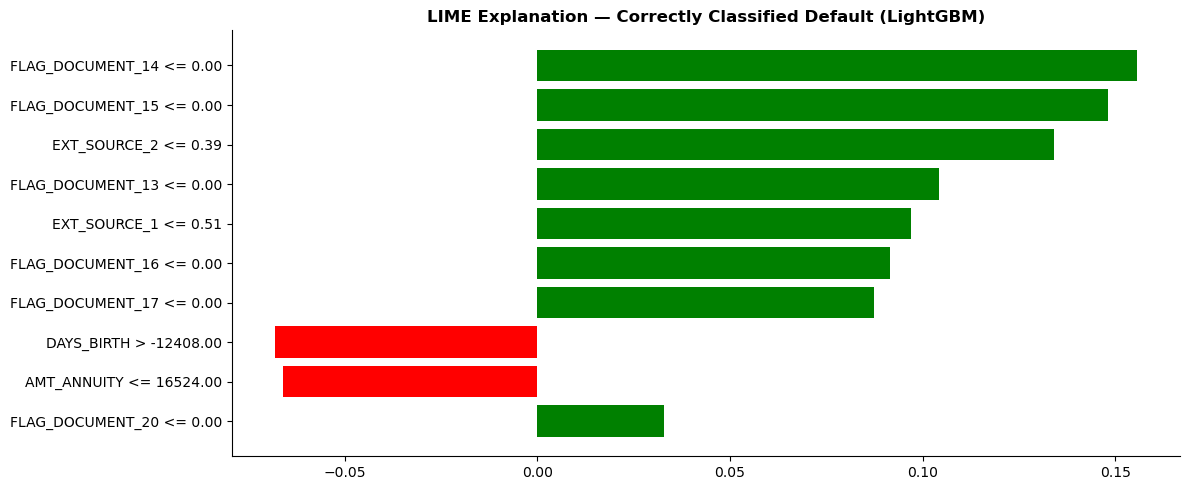

Saved: lime_explanation_correct.png


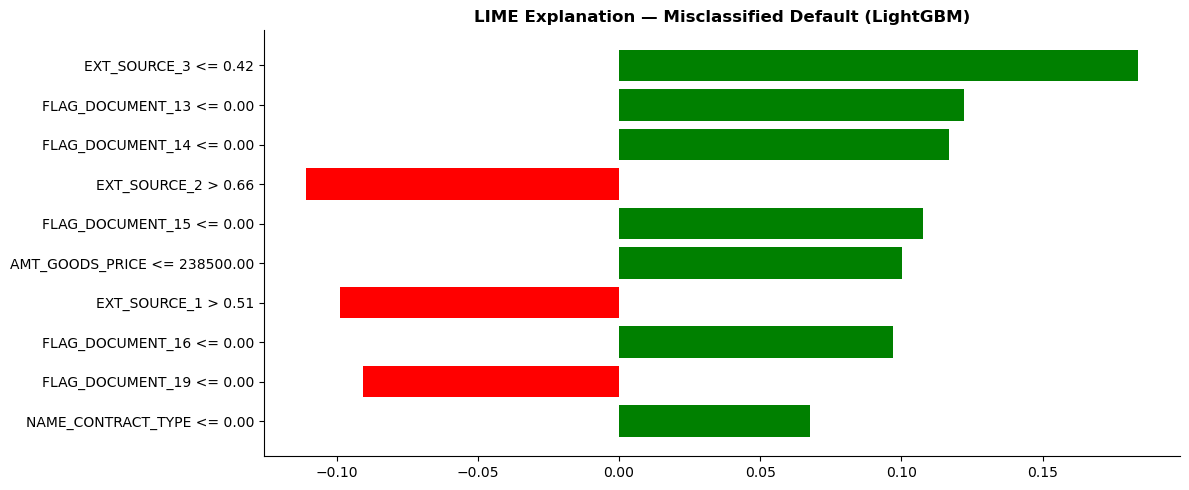

Saved: lime_explanation_missed.png


In [56]:
# LIME single instance explaination
# find one correctly classified and one misclassified instance
y_pred_lgbm = lgbm.predict(X_test_sample)

# correctly classified default (true=1, pred=1)
correct_idx = np.where(
    (y_test_sample.values == 1) & (y_pred_lgbm == 1)
)[0][0]

# misclassified default (true=1, pred=0)
missed_idx = np.where(
    (y_test_sample.values == 1) & (y_pred_lgbm == 0)
)[0][0]

print(f"Correctly classified default instance: index {correct_idx}")
print(f"Misclassified default instance: index {missed_idx}")

# generate and plot LIME explanation for correctly classified
np.random.seed(42)
exp_correct = lime_explainer.explain_instance(
    data_row     = X_test_sample.iloc[correct_idx].values,
    predict_fn   = lgbm.predict_proba,
    num_features = 10
)

fig = exp_correct.as_pyplot_figure()
plt.title('LIME Explanation — Correctly Classified Default (LightGBM)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('lime_explanation_correct.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: lime_explanation_correct.png")

# generate and plot LIME explanation for misclassified
np.random.seed(42)
exp_missed = lime_explainer.explain_instance(
    data_row     = X_test_sample.iloc[missed_idx].values,
    predict_fn   = lgbm.predict_proba,
    num_features = 10
)

fig = exp_missed.as_pyplot_figure()
plt.title('LIME Explanation — Misclassified Default (LightGBM)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('lime_explanation_missed.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: lime_explanation_missed.png")

In [57]:
# Spearman Correlation Table
spearman_table = pd.DataFrame({
    'Model'                    : ['LightGBM', 'XGBoost', 'Random Forest'],
    'SHAP vs LIME (Spearman)'  : [round(corr_lgbm, 4),
                                   round(corr_xgb, 4),
                                   round(corr_rf, 4)],
    'Common Features (top 10)' : [n_lgbm, n_xgb, n_rf]
})

print("Table 2 — SHAP vs LIME Feature Agreement")
print("="*50)
print(spearman_table.to_string(index=False))
print("="*50)

spearman_table.to_csv(
    '/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/shap_lime_spearman_table.csv',
    index=False
)
print("\nSaved: shap_lime_spearman_table.csv")

Table 2 — SHAP vs LIME Feature Agreement
        Model  SHAP vs LIME (Spearman)  Common Features (top 10)
     LightGBM                   0.0000                         5
      XGBoost                   0.6000                         4
Random Forest                  -1.0000                         3

Saved: shap_lime_spearman_table.csv


In [58]:
# save prediction results
save_path = '/Users/gemkrairiksh/Desktop/RMIT/SEM_3/THESIS/CreditRisk_ML/archive/processed/'

# save predicted probabilities and classes for all six models
predictions = pd.DataFrame({
    'y_true'              : y_test.values,
    'lr_prob'             : lr_prob,
    'lr_pred'             : lr_pred,
    'dt_prob'             : dt_prob,
    'dt_pred'             : dt_pred,
    'scorecard_prob'      : sc_prob,
    'scorecard_pred'      : sc_pred,
    'rf_prob'             : rf_prob,
    'rf_pred'             : rf_pred,
    'lgbm_prob'           : lgbm_prob,
    'lgbm_pred'           : lgbm_pred,
    'xgb_prob'            : xgb_prob,
    'xgb_pred'            : xgb_pred
})

predictions.to_csv(save_path + 'test_predictions.csv', index=False)

print(f"Predictions saved: {predictions.shape}")
print(f"Rows: {len(predictions):,} (matches test set size)")
print("\nColumns saved:")
for col in predictions.columns:
    print(f"  {col}")

Predictions saved: (46127, 13)
Rows: 46,127 (matches test set size)

Columns saved:
  y_true
  lr_prob
  lr_pred
  dt_prob
  dt_pred
  scorecard_prob
  scorecard_pred
  rf_prob
  rf_pred
  lgbm_prob
  lgbm_pred
  xgb_prob
  xgb_pred
